<center>
    <h1><b>Feed Forward Neural Networks for Natural Language Processing<b></h1>
</center>

In this notebook we will explore the field of **Natural Language Processing** (NLP) and specifically we will develop a **sentiment classifier** using **feed forward neural networks**. We are going to use a twitter dataset containing users comments. This dataset is splitted into training, validation and testing data.

### Theme Configuration

In [1]:
theme = 'light'  # Adjust this variable to 'light' for light mode or 'dark' for dark mode

# Initialize some variables that define the colors of the plotting graphs
patch_background_color = '#0D0D0D' if theme == 'dark' else 'white'
plot_background_color = '#0D0D0D' if theme == 'dark' else 'white'
ax_background_color = '#111111' if theme == 'dark' else '#F0F0F0'
plot_grid_color = '#252525' if theme == 'dark' else 'lightgrey'
text_color = '#FFFFFF' if theme == 'dark' else 'black'

## Dataset Preperation
### Data Loading
We will start by loading the data that we are going to work with. This dataset contains **training, validation and testing** data. Data Preprocessing and EDA were briefly explaind in the first notebook **TF-IDF and Logistic Regression in NLP**. We will use the preprocessing techniques in this notebook too.

In [2]:
import pandas as pd
import warnings

warnings.filterwarnings("ignore") # Ignore warnings
warnings.filterwarnings("ignore", category=UserWarning, module="nltk")

# Set the dataset path
base_folder = ""
dataset_base_filepath = base_folder + "/kaggle/input/ai-2-dl-for-nlp-2025-homework-2"

# Load all the dataset files using pandas and store inside some dataframe variables
train_df = pd.read_csv(f'{dataset_base_filepath}/train_dataset.csv')
val_df = pd.read_csv(f'{dataset_base_filepath}/val_dataset.csv')
test_df = pd.read_csv(f'{dataset_base_filepath}/test_dataset.csv')

# Reduce the data sizes (0 to 1 - For testing purposes)
size=1
train_df = train_df.sample(frac=size)
val_df = val_df.sample(frac=size)
test_df = test_df.sample(frac=size)

print(train_df.shape, val_df.shape, test_df.shape)

(148388, 3) (42396, 3) (21199, 2)


As we can see our training and validation data contain 148388 samples and 3 features. The features used are **'ID', 'Text', and 'Label'**. Let's have a closer look on our training data.

In [3]:
train_df.head() # Render the first 5 samples of training data

,ID,Text,Label
40012,84594,When was the last time I went out and had a re...,0
92153,199931,@SocialMtgExpert Sorry for my forum reply on @...,0
65315,61710,"@cdnsma yeah, a certain song is definitely goi...",1
127909,61585,Today was my sisters baby shower! It was so ni...,1
45758,127801,"@Aintialady thanks for the follow Friday btw, ...",1


### Data Preprocessing
As we mentioned previously we are going to use the same preprocess techniques as in the first notebook. For this we will install some **Python libraries** (nltk, contractions).

#### Installing Libraries
We will start by installing some supporting libraries for the data preprocessing step.

In [4]:
# Install some useful libraries for processing
%pip install contractions
%pip install nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.9/289.9 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.3/118.3 kB 4.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


#### Downloading stop-words packages
We now install some packages that will help us remove **stop-words** from the data. Stop-words removal will be part of the data preprocessing, at least for now.

In [5]:
import os
import nltk
from nltk.corpus import wordnet

warnings.filterwarnings("ignore", category=UserWarning, module="nltk")

# Download nltk packages
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

#### Stemmer and Lemmatizer definition
**Stemming** and **Lemmatization** will also take place on the preprocessing procedure. So we define a stemmer and a lemmatizer.

In [6]:
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Initialize a stemmer and a lemmatizer
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

#### Basic Preprocessing
We will now define a function for basic preprocessing of the data. This function is provided by the first notebook of the project **'TF-IDF and Logistic Regression in NLP'**. This procedure contains:
1. Text convertion to lowercase
2. Removal of web links ('https...'), user mentions ('@...') and hashtags ('#...')
3. Panctuation deletion.
4. Stemming and lemmatization.
5. Removal of digits, extra spaces, special characters and more.

In [7]:
import re
import contractions

!unzip /usr/share/nltk_data/corpora/wordnet.zip -d /usr/share/nltk_data/corpora/

# Provided by first notebook
def clean_text(text: str) -> str:
    """ Basic string preprocessing function. """
    text = text.lower() # Convert to lowercase
    text = contractions.fix(text) # Expand contractions
    text = re.sub(r"http\S+|www\S+|https\S+", "", text) # Remove url links
    text = re.sub(r"@\w+", "", text) # Remove mentions
    text = re.sub(r"#(\w+)", "", text) # Remove hastags
    text = re.sub(r"(?<!\.)\.(?!\.)|[^\w\s\?\!]", "", text)
    text = re.sub(r"\.\.\.", " ... ", text)  # Ensure '...' is treated as a single token

    text = re.sub(r"&[^;\s]+;", "", text) # Remove special characters
    text = re.sub(r"\s+", " ", text) # Remove extra spaces

    text = re.sub(r"\d+", "", text)

    words = text.split()
    stemmed_words = [stemmer.stem(word) for word in words] # Apply stemming
    lemmatized_words = [lemmatizer.lemmatize(word) for word in stemmed_words] # Apply lemmatization
    text = " ".join(lemmatized_words)

    return text

Archive:  /usr/share/nltk_data/corpora/wordnet.zip
   creating: /usr/share/nltk_data/corpora/wordnet/
  inflating: /usr/share/nltk_data/corpora/wordnet/lexnames  
  inflating: /usr/share/nltk_data/corpora/wordnet/data.verb  
  inflating: /usr/share/nltk_data/corpora/wordnet/index.adv  
  inflating: /usr/share/nltk_data/corpora/wordnet/adv.exc  
  inflating: /usr/share/nltk_data/corpora/wordnet/index.verb  
  inflating: /usr/share/nltk_data/corpora/wordnet/cntlist.rev  
  inflating: /usr/share/nltk_data/corpora/wordnet/data.adj  
  inflating: /usr/share/nltk_data/corpora/wordnet/index.adj  
  inflating: /usr/share/nltk_data/corpora/wordnet/LICENSE  
  inflating: /usr/share/nltk_data/corpora/wordnet/citation.bib  
  inflating: /usr/share/nltk_data/corpora/wordnet/noun.exc  
  inflating: /usr/share/nltk_data/corpora/wordnet/verb.exc  
  inflating: /usr/share/nltk_data/corpora/wordnet/README  
  inflating: /usr/share/nltk_data/corpora/wordnet/index.sense  
  inflating: /usr/share/nltk_data

We will apply the above function to the training, validation, and testing datasets and see the results. We will also count the time elapsed for the preprocessing step.

In [8]:
import time

# Drop nan values and duplicates from the datasets
train_df.dropna(inplace=True)
train_df.drop_duplicates(inplace=True)
val_df.dropna(inplace=True)
val_df.drop_duplicates(inplace=True)
test_df.dropna(inplace=True)
test_df.drop_duplicates(inplace=True)

# Apply the cleaning function to every dataset file and create a new column with the modified text
print("Preprocessing the datasets...")
start_time = time.time()
train_df["Cleaned_text"] = train_df["Text"].apply(clean_text)
val_df["Cleaned_text"] = val_df["Text"].apply(clean_text)
test_df["Cleaned_text"] = test_df["Text"].apply(clean_text)
end_time = time.time()
print("Preprocessing done!")

print(f"Datasets were cleaned in {end_time - start_time} seconds.")
train_df.head(10)

Preprocessing the datasets...
Preprocessing done!
Datasets were cleaned in 52.59487009048462 seconds.


,ID,Text,Label,Cleaned_text
40012,84594,When was the last time I went out and had a re...,0,when wa the last time i went out and had a rea...
92153,199931,@SocialMtgExpert Sorry for my forum reply on @...,0,sorri for my forum repli on it wa never meant ...
65315,61710,"@cdnsma yeah, a certain song is definitely goi...",1,yeah a certain song is definit go to make an a...
127909,61585,Today was my sisters baby shower! It was so ni...,1,today wa my sister babi shower! it wa so nice ...
45758,127801,"@Aintialady thanks for the follow Friday btw, ...",1,thank for the follow friday by the way i got y...
56954,165945,Who'd like to sleep,0,who would like to sleep
71338,19591,on my way to see my gg....she not feelin too g...,0,on my way to see my ggshe not feelin too good!
78622,84598,@elesbells you walked past me and jess going t...,0,you walk past me and jess go to soundcheck i c...
96714,111520,@davidghc Good stuff! Keep it going!,1,good stuff! keep it going!
32119,27408,dinner soon ... ~I'm holding on to somethin...,1,dinner soon i am hold on to someth that use to...


#### Stop-words Removal
We will continue by removing some stop-words from the dataset. We will also define a function for this below. Again this function is part of the first notebook and removes some specific stop-words (personal choice) from the dataset.

In [9]:
from nltk.tokenize import word_tokenize

# Provided by the first notebook
def remove_stopwords(text: str) -> str:
    """ String Stop-words removal function """
    # Remove the stopwords from the original text
    stop_words = set(
        ["i", "to", "the", "is", "a", "you", "my", "and",
         "it", "am", "for", "in", "of", "that", "on", "so", "me"]
    )
    word_tokens = word_tokenize(text)
    filtered_words = [word for word in word_tokens if word not in stop_words]

    return " ".join(filtered_words)

Let's apply this function to the datasets and capture the time elapsed.

In [10]:
start_time = time.time()
train_df['Cleaned_text'] = train_df['Cleaned_text'].apply(remove_stopwords)
val_df['Cleaned_text'] = val_df['Cleaned_text'].apply(remove_stopwords)
test_df['Cleaned_text'] = test_df['Cleaned_text'].apply(remove_stopwords)
end_time = time.time()

print(f"Stopwords were removed in {end_time - start_time} seconds.")
train_df.head()

Stopwords were removed in 19.896095991134644 seconds.


,ID,Text,Label,Cleaned_text
40012,84594,When was the last time I went out and had a re...,0,when wa last time went out had realli good tim...
92153,199931,@SocialMtgExpert Sorry for my forum reply on @...,0,sorri forum repli wa never meant be snotti at ...
65315,61710,"@cdnsma yeah, a certain song is definitely goi...",1,yeah certain song definit go make an appear
127909,61585,Today was my sisters baby shower! It was so ni...,1,today wa sister babi shower ! wa nice she got ...
45758,127801,"@Aintialady thanks for the follow Friday btw, ...",1,thank follow friday by way got next week k ?


### Data Vectorization
In order to use our datasets to train a model, we need a method to turn our datasets into numeric values. In other words we need to **vectorize** our data.

#### Downloading GloVe Embeddings
There is a variety of vectorizing techniques like TF-IDF that we used in the first notebook. This time we will use a techinque called word2vec, and specifically we will use already constructed word embeddings. The library we will use is called **GloVe Embeddings**.

In [11]:
import urllib.request
import zipfile
import os

# Make the folder that will contain the embeddings for later use
glove_folder = '../glove_data'
os.makedirs(glove_folder, exist_ok=True)

# URL of the GloVe zip file
glove_url = "http://nlp.stanford.edu/data/glove.6B.zip"
zip_path = os.path.join(glove_folder, "glove.6B.zip")

if not os.path.exists(zip_path):
    # Download the zip
    print("Downloading GloVe embeddings...")
    urllib.request.urlretrieve(glove_url, zip_path)

    # Unzip
    print("Unzipping...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(glove_folder)
    print("Done! GloVe is saved to:", glove_folder)

else:
    print("GloVe embeddings already downloaded.")

print("Ready to use GloVe from:", glove_folder)

Unzipping...
Done! GloVe is saved to: ../glove_data
Ready to use GloVe from: ../glove_data


By downloading GloVe embeddings we have access to 4 files containing several words of the english language and their corresponding vector representation. The difference in the 4 files is the dimension of the vectors. Specifically we 4 representations of words (3 types of dimension):
1. Representation in 50 dimensions (50 numeric values)
2. Representation in 100 dimensions (100 numeric values)
3. Representation in 200 dimensions (200 numeric values)
4. Representation in 300 dimensions (300 numeric values)

#### Loading the embeddings
Next we will load our embeddings to our workspace. We will start by loading the representation of words in 50 dimensions.

In [12]:
import numpy as np

# Loads the embeddings according to the given file path
def load_glove(glove_path):
  embeddings = {}
  with open(glove_path, 'r', encoding='utf-8') as f:
    for line in f:
      values = line.split()
      word = values[0]
      vector = np.asarray(values[1:], dtype='float32')
      embeddings[word] = vector

  return embeddings

In [13]:
embeddings_dim = 50 # Can be 50, 100, 200, or 300
glove_path = f'{glove_folder}/glove.6B.{embeddings_dim}d.txt'

embeddings = load_glove(glove_path) # Load the glove embeddings
print(f'Loaded {len(embeddings)} word vectors.')

Loaded 400000 word vectors.


As we see there are 400.000 total words represented as vectors.

#### Exploring the emebddings

##### Vector Representation of words
Let's have a closer look to the embeddings and see how some words are represented. We will build a function that creates a dictionary of the words and their corresponding vector representation.

In [14]:
def get_w2v_dictionary(glove_path, num_words=22):
  dictionary = {}

  # Try to open the file and read the first num_words lines and store them in the dictionary
  try:
    with open(glove_path, 'r', encoding='utf-8') as f:
      for i, line in enumerate(f):
        if i >= num_words:
          break
        parts = line.strip().split()
        word = parts[0]
        vector = list(map(float, parts[1:]))
        dictionary[word] = f"[{', '.join(map(str, vector))}]"

  # Handle the case where the file cannot be opened or is not found
  except Exception as e:
    print(f"Error: File {glove_path} not found or cannot be opened.")

  return dictionary

Next we will take the output of this function for the 50 dimensions representation of words and construct a pandas dataframe to represent the results.

In [15]:
# Read the contents of the glove file and store them in a dictionary
w2v_dictionary = get_w2v_dictionary(glove_path, num_words=22)

# Create a dataframe from the dictionary
w2v_df = pd.DataFrame.from_dict(w2v_dictionary, orient='index')
w2v_df.reset_index(inplace=True)
w2v_df.columns = ['Word', 'Vector']

w2v_df.head(10)

,Word,Vector
0,the,"[0.418, 0.24968, -0.41242, 0.1217, 0.34527, -0..."
1,",","[0.013441, 0.23682, -0.16899, 0.40951, 0.63812..."
2,.,"[0.15164, 0.30177, -0.16763, 0.17684, 0.31719,..."
3,of,"[0.70853, 0.57088, -0.4716, 0.18048, 0.54449, ..."
4,to,"[0.68047, -0.039263, 0.30186, -0.17792, 0.4296..."
5,and,"[0.26818, 0.14346, -0.27877, 0.016257, 0.11384..."
6,in,"[0.33042, 0.24995, -0.60874, 0.10923, 0.036372..."
7,a,"[0.21705, 0.46515, -0.46757, 0.10082, 1.0135, ..."
8,"""","[0.25769, 0.45629, -0.76974, -0.37679, 0.59272..."
9,'s,"[0.23727, 0.40478, -0.20547, 0.58805, 0.65533,..."


##### Words similarity using vectors
GloVe embeddings also support operations between vectorized words. This feature leads us to some interesting experiments that we will take place now. First we will try to get the most similar words to a given one. For this we will also develop a function.

In [16]:
# Finds the most similar words to a given word
def find_most_similar_words(word, embeddings, top_n=5):
  if word not in embeddings:
    print(f"Word '{word}' not found in embeddings.")
    return []

  word_vector = embeddings[word]
  similarities = {}

  for other_word, other_vector in embeddings.items():
    if other_word != word:
      similarity = np.dot(word_vector, other_vector) / (np.linalg.norm(word_vector) * np.linalg.norm(other_vector))
      similarities[other_word] = similarity

  # Sort the words by similarity and return the top_n most similar words
  most_similar_words = sorted(similarities.items(), key=lambda x: x[1], reverse=True)[:top_n]
  return most_similar_words

Let's try this function for the word 'technology'. We will also print the similarity score of each word that says how much the current word is similar to 'technology'.

In [17]:
# Get the most similar words to "technology"
example_word = 'technology'
most_similar_words = find_most_similar_words(example_word, embeddings, top_n=10)

print(f'Most semantically similar to word {example_word}:')
print(f'\n{" "*5}word{" "*10}  similarity score')
print(f'{"="*43}')
for w in most_similar_words:
  print(f'{" "*5}{w[0]:15}{w[1]}')

Most semantically similar to word technology:

     word            similarity score
     technologies   0.892826497554779
     computer       0.8525559306144714
     systems        0.8289325833320618
     software       0.8089752793312073
     computing      0.7991362810134888
     innovation     0.7875596284866333
     business       0.7863730192184448
     tool           0.7848256230354309
     developed      0.7802093625068665
     research       0.7735083699226379


##### Word Operations
GloVe Embeddings let us apply actual operations on words, and specifically on their vector representation. Let's take two words **'apple'** and **'technology'** and compute the operations:
1. apple - technology
2. apple + technology

and see the results. We will first build some supporting functions for this.

In [18]:
# Computes the euclidean distance between two vectors
def euclidean_distance(v1, v2):
  return np.linalg.norm(v1 - v2)

# Finds the closest word (vector) to a given one (vector)
def find_closest_word(target_vector, excluded_words, embeddings):
  min_distance = float('inf')
  closest_word = None
  for other_word, other_vector in embeddings.items():
    if other_word in excluded_words:
      continue
    current_distance = euclidean_distance(target_vector, other_vector)
    if current_distance < min_distance:
      min_distance = current_distance
      closest_word = other_word
  return closest_word

Let's try this

In [19]:
# Calculate the semantics: word1 - word2 and word1 + word2
word1, word2 = 'apple', 'technology'

if word1 in embeddings and word2 in embeddings:
  word1_vector = embeddings[word1]
  word2_vector = embeddings[word2]

  # Calculate word1 - word2
  result_vector_minus = word1_vector - word2_vector
  closest_word_minus = find_closest_word(result_vector_minus, [word1, word2], embeddings)
  print(f'Closest word to {word1} - {word2} is: {closest_word_minus}')

  # Calculate word1 + word2
  result_vector_plus = word1_vector + word2_vector
  closest_word_plus = find_closest_word(result_vector_plus, [word1, word2], embeddings)
  print(f'Closest word to {word1} + {word2} is: {closest_word_plus}')

Closest word to apple - technology is: nectarine
Closest word to apple + technology is: software


##### Words Vectors Visualization
Finally we will try to visualize the embeddings to the 2D space. Since our words are represented in the 50-dimension space, we will have to apply some **dimensionality reduction** to the data. Specifically we will use **PCA**. Let's construct some functions that will apply PCA to the data and produce a 2D plot of the words. We will also consider to visualise several **words categories** to see the difference of the words in action.

In [20]:
def collect_vectors(categories, embeddings):
    all_vectors = []
    colors = []
    category_labels = []

    for category in categories:
        words = category["items"]
        color = category["color"]
        label = category["category"]
        for word in words:
            if word in embeddings:
                all_vectors.append(embeddings[word])
                colors.append(color)
                category_labels.append(label)

    return all_vectors, colors, category_labels

In [21]:
from sklearn.decomposition import PCA

def reduce_dimensions(vectors, n_components=2):
    pca = PCA(n_components=n_components)
    return pca.fit_transform(np.array(vectors))

In [22]:
import matplotlib.pyplot as plt

def configure_plot(ax):
    ax.set_facecolor(plot_background_color)
    ax.tick_params(axis='both', colors=text_color)
    for spine in ax.spines.values():
        spine.set_edgecolor(text_color)

In [23]:
import matplotlib.pyplot as plt

def plot_reduced_vectors(ax, reduced_vectors, colors, category_labels):
    unique_categories = set(category_labels)
    for category in unique_categories:
        indices = [i for i, label in enumerate(category_labels) if label == category]
        ax.scatter(
            [reduced_vectors[i, 0] for i in indices],
            [reduced_vectors[i, 1] for i in indices],
            color=colors[indices[0]],
            label=category,
            s=10,
        )

In [24]:
def finalize_plot():
    plt.title("Word Embeddings in 2D Space", color=text_color)
    plt.xlabel("PCA Component 1", color=text_color)
    plt.ylabel("PCA Component 2", color=text_color)
    plt.grid(color=plot_grid_color)
    plt.legend(loc='best', fontsize=8, labelcolor=text_color).get_frame().set_facecolor(patch_background_color)
    plt.xlim(-5, 6)
    plt.ylim(-5, 6)
    plt.tight_layout()
    plt.show()

In [25]:
import matplotlib.pyplot as plt

def plot_words_2d(categories, embeddings):
    all_vectors, colors, category_labels = collect_vectors(categories, embeddings)

    if not all_vectors:
        print("No valid words found in embeddings.")
        return

    reduced_vectors = reduce_dimensions(all_vectors)

    fig, ax = plt.subplots(figsize=(4, 4))
    fig.patch.set_facecolor(patch_background_color)

    configure_plot(ax)
    plot_reduced_vectors(ax, reduced_vectors, colors, category_labels)
    finalize_plot()

Let's try this function by visuzlising several words for the categories: 'fruits', 'animals', 'colors' and 'vehicles'.

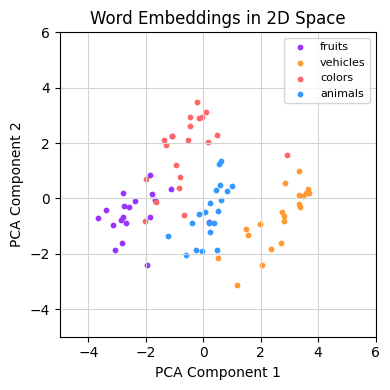

In [26]:
# Example categories to plot
categories = [
  {"category": "fruits", "items": ["banana", "apple", "mango", "strawberry", "coconut", "orange", "grape", "pineapple", "watermelon", "peach"], "color": "#9933FF"},
  {"category": "animals", "items": ["dog", "cat", "lion", "tiger", "elephant", "zebra", "giraffe", "rabbit", "bear", "wolf"], "color": "#3399FF"},
  {"category": "colors", "items": ["red", "blue", "green", "purple", "orange", "pink", "yellow", "brown", "black", "white"], "color": "#FF6666"},
  {"category": "vehicles", "items": ["car", "bus", "train", "airplane", "bicycle", "motorcycle", "boat", "truck", "scooter", "submarine"], "color": "#FF9933"}
]
# Add more items to each category
categories[0]["items"].extend(["kiwi", "papaya", "plum", "cherry", "apricot", "pear", "fig", "pomegranate", "lychee", "guava"])
categories[1]["items"].extend(["fox", "deer", "kangaroo", "panda", "koala", "cheetah", "leopard", "hippopotamus", "rhinoceros", "crocodile"])
categories[2]["items"].extend(["cyan", "magenta", "teal", "maroon", "navy", "lavender", "beige", "turquoise", "gold", "silver"])
categories[3]["items"].extend(["helicopter", "spaceship", "tractor", "hovercraft", "skateboard", "rollerblades", "segway", "yacht", "jet", "gondola"])
# Plot the categories
plot_words_2d(categories, embeddings)

Let's also visualise them in the 3D space.

In [27]:
from mpl_toolkits.mplot3d import Axes3D

def reduce_dimensions_3d(vectors):
    ''' Reduces the dimensions of the vectors to 3D using PCA '''
    pca = PCA(n_components=3)
    return pca.fit_transform(np.array(vectors))

In [28]:
def collect_vectors_and_reduce_3d(categories, embeddings):
    ''' Collects vectors from categories and reduces them to 3D '''
    all_vectors, colors, category_labels = collect_vectors(categories, embeddings)

    if not all_vectors:
        print("No valid words found in embeddings.")
        return None, None, None

    reduced_vectors = reduce_dimensions_3d(all_vectors)
    return reduced_vectors, colors, category_labels


def configure_3d_plot(ax):
    ''' Configures the 3D plot appearance '''
    ax.xaxis.pane.set_color(ax_background_color)
    ax.yaxis.pane.set_color(ax_background_color)
    ax.zaxis.pane.set_color(ax_background_color)

    ax.xaxis.line.set_color(text_color)
    ax.yaxis.line.set_color(text_color)
    ax.zaxis.line.set_color(text_color)

    ax.xaxis._axinfo["grid"].update({"color": plot_grid_color})
    ax.yaxis._axinfo["grid"].update({"color": plot_grid_color})
    ax.zaxis._axinfo["grid"].update({"color": plot_grid_color})

    ax.set_facecolor(plot_background_color)
    ax.set_title("Word Embeddings in 3D Space", color=text_color)
    ax.set_xlabel("PCA Component 1", color=text_color)
    ax.set_ylabel("PCA Component 2", color=text_color)
    ax.set_zlabel("PCA Component 3", color=text_color)
    ax.tick_params(axis='both', colors=text_color)
    ax.tick_params(axis='z', colors=text_color)


def plot_3d_categories(ax, reduced_vectors, colors, category_labels):
    ''' Plots the categories in the 3D space '''
    unique_categories = set(category_labels)
    for category in unique_categories:
        indices = [i for i, label in enumerate(category_labels) if label == category]
        ax.scatter(
            [reduced_vectors[i, 0] for i in indices],
            [reduced_vectors[i, 1] for i in indices],
            [reduced_vectors[i, 2] for i in indices],
            color=colors[indices[0]],
            label=category
        )


def finalize_3d_plot(ax):
    ''' Finalizes the 3D plot with legend and layout adjustments '''
    ax.legend(loc='best', fontsize=10, labelcolor=text_color).get_frame().set_facecolor(patch_background_color)
    plt.rcParams['grid.color'] = plot_grid_color
    plt.tight_layout()
    plt.show()


def plot_words_3d(categories, embeddings):
    ''' Main function to plot GloVe embeddings in 3D space '''
    reduced_vectors, colors, category_labels = collect_vectors_and_reduce_3d(categories, embeddings)

    if reduced_vectors is None:
        return

    fig = plt.figure(figsize=(4, 4))
    ax = fig.add_subplot(111, projection='3d')
    fig.patch.set_facecolor(patch_background_color)

    configure_3d_plot(ax)
    plot_3d_categories(ax, reduced_vectors, colors, category_labels)
    finalize_3d_plot(ax)

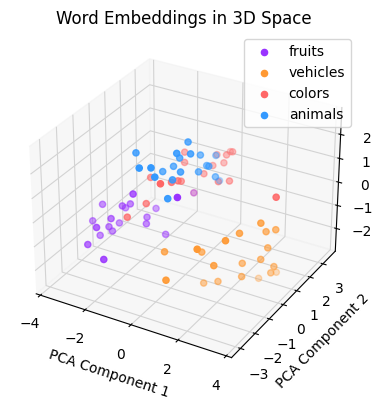

In [29]:
# Plot the categories in 3D
plot_words_3d(categories, embeddings)

Finally let's visualise the word using all the vectors dimensions that are available within the `glove6B.zip` 

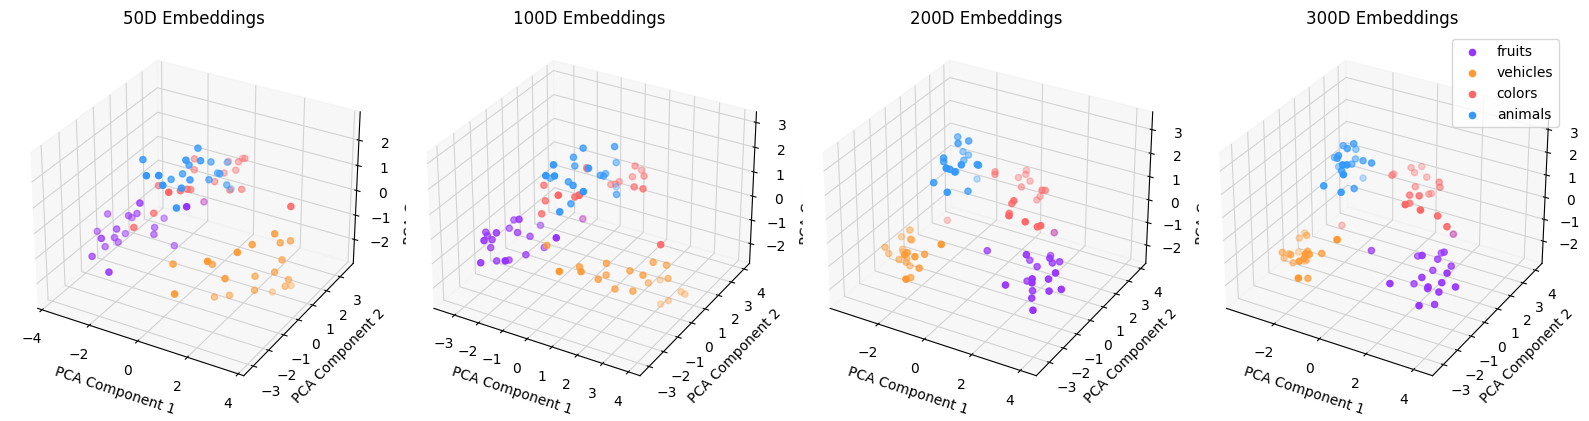

In [30]:
# Define a function to visualize categories of words for different embedding dimensions in 3D
def visualize_categories_for_dimensions_3d(categories, glove_folder, dimensions):
    fig = plt.figure(figsize=(len(dimensions) * 4, 4))  # Adjust figure size to fit all plots on the same line
    fig.patch.set_facecolor(patch_background_color)
    for i, dim in enumerate(dimensions):
        glove_path = f"{glove_folder}/glove.6B.{dim}d.txt"
        embeddings = load_glove(glove_path)
        
        # Collect and reduce vectors to 3D
        reduced_vectors, colors, category_labels = collect_vectors_and_reduce_3d(categories, embeddings)
        if reduced_vectors is None:
            continue

        # Create a subplot for each dimension
        ax = fig.add_subplot(1, len(dimensions), i + 1, projection='3d')
        configure_3d_plot(ax)
        plot_3d_categories(ax, reduced_vectors, colors, category_labels)
        ax.set_title(f"{dim}D Embeddings", color=text_color)

    finalize_3d_plot(ax)

# List of dimensions to visualize
embedding_dimensions = [50, 100, 200, 300]

# Visualize the categories for each embedding dimension in 3D
visualize_categories_for_dimensions_3d(categories, glove_folder, embedding_dimensions)

### Model Training
Now it is time to traing our first model and see the results. In this notebook we focus on the **feed forward neural networks** (Feed Forward NNs) and we are going to execute several experiments following their architecture.

#### Dummy Model
We first build a very simple model that all it does is making random predictions. This model is not trained at all and that is why we call it as **dummy** model.

In [31]:
import random

class DummyModel:
    def __init__(self, output_dim):
        self.output_dim = output_dim

    def predict(self, num_samples):
        """Generate random predictions for the given number of samples."""
        return [random.randint(0, self.output_dim - 1) for _ in range(num_samples)]

# Example usage
dummy_model = DummyModel(output_dim=2)
num_samples = 10  # Number of predictions to generate
# Generate random predictions for the validation dataset
random_predictions = dummy_model.predict(len(val_df))

# Compute the accuracy of the dummy model
correct_predictions = sum(
    [1 for pred, true_label in zip(random_predictions, val_df['Label']) if pred == true_label]
)
accuracy = correct_predictions / len(val_df)

print(f"Accuracy of the dummy model on validation data: {accuracy:.4f}")
print(f"Random predictions: {random_predictions}")

Accuracy of the dummy model on validation data: 0.4948
Random predictions: [0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 

#### Base Model
We will start by defining the base model of our project, where its is going to be a **basic neural network**, with a **simple architecture**.

##### Supporting functions and structures
Before we dive into the model creating process, we need to define a function that **transforms** a specific **tweet** to a **vector**, and a **structure** that will play **significant role** in the **training** and **testing** procesdures of the network.

In [32]:
from nltk.util import ngrams

def tweet_to_vector(tokens, embeddings, embeddings_dim, ngram_range=(1, 1)):
    ''' Transforms a tweet (list of tokens) to a vector using n-grams. '''
    ngram_vectors = []

    # Iterate through the desired range of n-gram sizes
    for n in range(ngram_range[0], ngram_range[1] + 1):
        # Generate n-grams from the tokens
        for ngram in ngrams(tokens, n):
            # Compute the average embedding for the n-gram
            vectors = [embeddings[word] for word in ngram if word in embeddings]
            if vectors:
                ngram_vectors.append(np.mean(vectors, axis=0))

    # If no n-grams have embeddings, return a zero vector
    if not ngram_vectors:
        return np.zeros(embeddings_dim)

    # Return the average vector of all n-grams
    return np.mean(ngram_vectors, axis=0)

In [33]:
import torch
from torch.utils.data import Dataset

class TextDataset(Dataset):
    ''' Supporting structure (collection) that keeps tweet samples to be used in training and validating '''

    def __init__(self, texts, labels, embeddings, embeddings_dim, ngram_range=(1, 1)):
        self.texts = texts
        self.labels = labels
        self.embeddings = embeddings
        self.embeddings_dim = embeddings_dim
        self.ngram_range = ngram_range

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        vector = tweet_to_vector(text.split(), self.embeddings, self.embeddings_dim, self.ngram_range)
        return torch.tensor(vector, dtype=torch.float32), torch.tensor(label, dtype=torch.long)

In [34]:
class TestTextDataset(Dataset):
    ''' Supporting structure (collection) that keeps tweet samples to be used in testing '''

    def __init__(self, texts, embeddings, embeddings_dim, ngram_range=(1, 1)):
        self.texts = texts
        self.embeddings = embeddings
        self.embeddings_dim = embeddings_dim
        self.ngram_range = ngram_range

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        vector = tweet_to_vector(text.split(), self.embeddings, self.embeddings_dim, self.ngram_range)
        return torch.tensor(vector, dtype=torch.float32)

In [35]:
import time

def notify(start_message, end_message):
    ''' Decorator to time a procedure and print a message before and after it '''
    def wrapper(func):
        ''' Inner wrapper of the decorator '''
        def inner(*args, **kwargs):
            print(start_message)
            start_time = time.time()
            func_result = func(*args, **kwargs)
            end_time = time.time()
            print(f'{end_message} | Time elapsed: {end_time - start_time} seconds')
            return func_result
        return inner
    return wrapper

##### Model Definition
After defining these structures, we will define our model. The architecture we are going to use in this step is very simple. Specifically the model will consists of **hidden layer** that is going to have **128 neurals**. We will not use any activation function in this step either.

In [36]:
import torch.nn as nn

class SentimentClassifier_V1(nn.Module):
  '''
  Base Model of the sentiment classifier project (Version 1).
  - 1 hidden layer
  - 128 neurals
  - No activation function
  '''
  def __init__(self, input_dim, output_dim):
    super(SentimentClassifier_V1, self).__init__()

    # Define the fully connected layers of the network
    self.fc1 = nn.Linear(input_dim, 128)
    self.fc2 = nn.Linear(128, output_dim)

  def forward(self, x):
    # Pass the input data through the fully connected layers and return the result
    x = self.fc1(x)
    x = self.fc2(x)
    return x

##### Using GPU
We will also connect to a **CUDA (GPU)** device (if possible) for better performance. We will have to pass our model and other structures to the current device. We will also set random seed that can help us achieve more consistent results.

In [37]:
import torch

# Connect to a cuda device if this is possible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [38]:
import random
import numpy as np
import torch

# Set random seed for Python, numpy and PyTorch
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

##### Constructing the Dataloaders
In order to train and test our model we need to construct some **Pytorch Dataloaders** to pass our data through the network as **batches**. We will use the structure we built before and create the dataloaders for our training and validation data.

In [39]:
from torch.utils.data import DataLoader

# Create a TextDataset structure for both training and validation datasets
ngram_range = (1, 1)
train_dataset = TextDataset(train_df['Cleaned_text'].reset_index(drop=True), train_df['Label'].reset_index(drop=True), embeddings, embeddings_dim, ngram_range=ngram_range)
validation_dataset = TextDataset(val_df['Cleaned_text'].reset_index(drop=True), val_df['Label'].reset_index(drop=True), embeddings, embeddings_dim, ngram_range=ngram_range)

# Construct a Pytorch Dataloader for these datasets
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=256, shuffle=False)

##### Define Hyperparameters
The last step id to define some hyperparameters that will be used in the training process of the network. Specifically we will use:
1. Max epochs = 10
2. learning rate ($\alpha$) = 0.001
3. criterion (loss function) = Cross Entropy
4. optimizer = Adam

In [40]:
# Define the input and output dimensions of the network
input_dim = embeddings_dim
output_dim = len(set(train_df['Label']))  # Number of unique labels

# First define a model using the base architecture
model_v1 = SentimentClassifier_V1(input_dim, output_dim).to(device)

# Then define the hyperparameters of the training process
epochs = 10
learning_rate = 0.001
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_v1.parameters(), lr=learning_rate)

##### Training the model
It is time to train our model. We will define a function for model training that will also keep track of the **training** and **validation loss** and the **validation accuracy** during the training procedure.

In [41]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    ''' Trains a given model for one epoch '''

    # Set the model to training mode and initialize the batch losses
    model.train()
    batch_losses = []

    # For every batch in the dataloader train the model
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        batch_losses.append(loss.item())

        # Upgrade the weights of the network using backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Compute the average loss of the model and return it
    avg_loss = sum(batch_losses) / len(batch_losses)
    return avg_loss

In [42]:
def validate_one_epoch(model, validation_loader, criterion, device):
    ''' Validates the model for one epoch '''

    # Set the model to evaluation mode and initializes the validation losses
    model.eval()
    val_losses = []
    correct, total = 0, 0

    # For every batch in the dataloader validate the model (keep its loss and accuracy)
    with torch.no_grad():
        for X_val, y_val in validation_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)
            y_val_pred = model(X_val)
            val_loss = criterion(y_val_pred, y_val)
            val_losses.append(val_loss.item())

            _, predicted = torch.max(y_val_pred, 1)
            correct += (predicted == y_val).sum().item()
            total += y_val.size(0)

    # Compute the average loss and the accuracy and return them
    avg_loss = sum(val_losses) / len(val_losses)
    accuracy = correct / total
    return avg_loss, accuracy

In [43]:
@notify('Training Process Started. ', 'Training Process Done!')
def train_model(model, train_loader, validation_loader, criterion, optimizer, device, epochs):
    ''' Traing a given model with a specific set of hyperparameters '''

    print(f'Training for {epochs} epochs...')

    # Initialize the training and validation losses, and the validation accuracies
    train_epoch_losses = []
    val_epoch_losses = []
    val_epoch_accuracies = []

    # Traing the model for a specific number of epochs
    for epoch in range(epochs):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_accuracy = validate_one_epoch(model, validation_loader, criterion, device)

        # Keep track of the model loss and accuracy
        train_epoch_losses.append(train_loss)
        val_epoch_losses.append(val_loss)
        val_epoch_accuracies.append(val_accuracy)

        if epoch == 0 or epoch == epochs - 1 or epoch % max(1, (epochs // 10)) == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Training Loss: {train_loss:.5f} ", end="")
            print(f"| Validation Loss: {val_loss:.5f} | Validation Accuracy: {val_accuracy:.4f}")

    return train_epoch_losses, val_epoch_losses, val_epoch_accuracies

Let's train our model

In [44]:
# Train the model with the above hyperparameters and get the loss and accuracy results
train_losses_v1, val_losses_v1, val_accuracies_v1 = train_model(
    model_v1, train_loader, validation_loader, criterion, optimizer, device, epochs
)

Training Process Started. 
Training for 10 epochs...
Epoch [1/10] | Training Loss: 0.62380 | Validation Loss: 0.61691 | Validation Accuracy: 0.6590
Epoch [2/10] | Training Loss: 0.61957 | Validation Loss: 0.61648 | Validation Accuracy: 0.6598
Epoch [3/10] | Training Loss: 0.61954 | Validation Loss: 0.61600 | Validation Accuracy: 0.6611
Epoch [4/10] | Training Loss: 0.61923 | Validation Loss: 0.61541 | Validation Accuracy: 0.6611
Epoch [5/10] | Training Loss: 0.61899 | Validation Loss: 0.61660 | Validation Accuracy: 0.6604
Epoch [6/10] | Training Loss: 0.61869 | Validation Loss: 0.61607 | Validation Accuracy: 0.6599
Epoch [7/10] | Training Loss: 0.61870 | Validation Loss: 0.61546 | Validation Accuracy: 0.6617
Epoch [8/10] | Training Loss: 0.61865 | Validation Loss: 0.61556 | Validation Accuracy: 0.6626
Epoch [9/10] | Training Loss: 0.61846 | Validation Loss: 0.61529 | Validation Accuracy: 0.6609
Epoch [10/10] | Training Loss: 0.61853 | Validation Loss: 0.61549 | Validation Accuracy: 0.6

##### Plotting the results
The training process has been completed, and the results are shown above. However it would be better and more understandable if we plotted the results obtained.

In [45]:
import matplotlib.pyplot as plt

def plot_results(train_losses, val_losses, val_accuracies):
    '''
    Plots the training and validation losses, and the validation accuracies obtained
    after the training process of a model.
    '''

    # Create a subplot figure and set the theme colors
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    fig.patch.set_facecolor(patch_background_color)

    # ----- Plot 1: Losses -----
    ax[0].set_facecolor(plot_background_color)
    ax[0].plot(train_losses, '-o', color='#0080FF', label='Training Loss')
    ax[0].plot(val_losses, '-o', color='#FF8000', label='Validation Loss')
    ax[0].set_title("Losses", color=text_color)
    ax[0].set_xlabel("Epoch", color=text_color)
    ax[0].set_ylabel("Loss", color=text_color)
    ax[0].tick_params(axis='both', colors=text_color)
    for spine in ax[0].spines.values():
        spine.set_edgecolor(text_color)
    ax[0].grid(color=plot_grid_color)
    ax[0].legend(loc='best', fontsize=12, labelcolor=text_color).get_frame().set_facecolor(patch_background_color)

    # ----- Plot 2: Validation Accuracy -----
    ax[1].set_facecolor(plot_background_color)
    ax[1].plot(val_accuracies, '-o', color='#00CC66', label='Validation Accuracy')
    ax[1].set_title("Validation Accuracy", color=text_color)
    ax[1].set_xlabel("Epoch", color=text_color)
    ax[1].set_ylabel("Accuracy", color=text_color)
    ax[1].tick_params(axis='both', colors=text_color)
    for spine in ax[1].spines.values():
        spine.set_edgecolor(text_color)
    ax[1].grid(color=plot_grid_color)
    ax[1].legend(loc='best', fontsize=12, labelcolor=text_color).get_frame().set_facecolor(patch_background_color)

    # Final adjustments
    plt.tight_layout()
    plt.show()

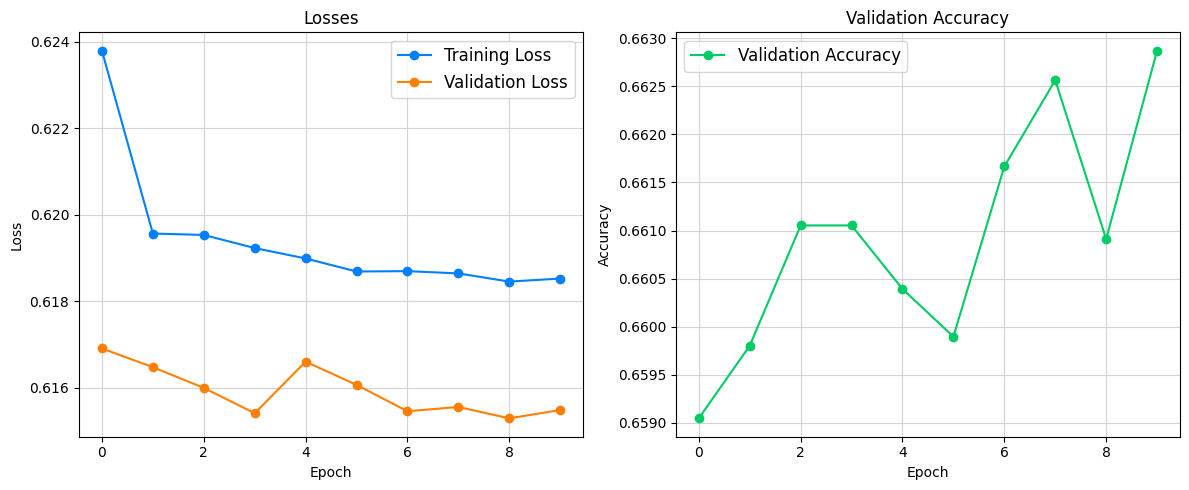

In [46]:
plot_results(train_losses_v1, val_losses_v1, val_accuracies_v1)

##### Evaluation and Different metrics
Finally, we will evaluate the model by computing the **accuacy** and other metrics **(precision, recall, and f1-score)**. Let's build a function for that.

In [47]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

@notify('Started evaluation...', 'Evaluation Done!')
def evaluate_model(model, data_loader):
  ''' Evaluates the model by returning accuracy, precision, recall, f1-score, and confusion matrix '''

  # Set the model to evaluation mode and initialize the true and predicted labels
  model.eval()
  all_labels, all_preds = [], []

  # Evaluate the model by testing every batch on the validation dataloader
  with torch.no_grad():
    for X_batch, y_batch in data_loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      y_pred = model(X_batch)
      _, predicted = torch.max(y_pred, 1)
      all_labels.extend(y_batch.cpu().numpy())
      all_preds.extend(predicted.cpu().numpy())

  # Compute accuracy, precision, recall, f1-score, and confusion matrix
  accuracy = accuracy_score(all_labels, all_preds)
  precision = precision_score(all_labels, all_preds, average='weighted')
  recall = recall_score(all_labels, all_preds, average='weighted')
  f1 = f1_score(all_labels, all_preds, average='weighted')
  conf_matrix = confusion_matrix(all_labels, all_preds)

  return accuracy, precision, recall, f1, conf_matrix

Let's evaluate the model

In [48]:
# Evaluate the model and get the metrics result
accuracy_v1, precision_v1, recall_v1, f1_score_v1, conf_matrix = evaluate_model(model_v1, validation_loader)

# Print the results
print(f"Validation Accuracy: {accuracy_v1:.4f}")
print(f"Validation Precision: {precision_v1:.4f}")
print(f"Validation Recall: {recall_v1:.4f}")
print(f"Validation F1 Score: {f1_score_v1:.4f}")

Started evaluation...
Evaluation Done! | Time elapsed: 8.190366506576538 seconds
Validation Accuracy: 0.6629
Validation Precision: 0.6636
Validation Recall: 0.6629
Validation F1 Score: 0.6625


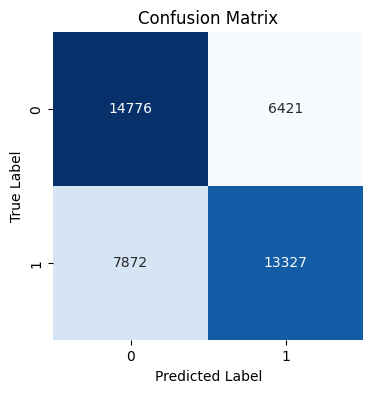

In [49]:
import seaborn as sns

# Plot the confusion matrix
def plot_confusion_matrix(ax, cm, classes):
    ''' Plots the confusion matrix '''
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=classes, yticklabels=classes, ax=ax
    )
    ax.set_title('Confusion Matrix', color=text_color)
    ax.set_xlabel('Predicted Label', color=text_color)
    ax.set_ylabel('True Label', color=text_color)
    ax.tick_params(colors=text_color)
    
    # Add 

# Get the unique labels from the training dataset and plot the confusion matrix
unique_labels = train_df['Label'].unique()
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
fig.patch.set_facecolor(patch_background_color)
plot_confusion_matrix(ax, conf_matrix, classes=unique_labels)
plt.show()


#### Apply Activation Functions
Our model has a very simple architecture, and we need to upgrade it to the next level. A very important feature of neural networks is **activation functions** since they help the model learn complex patterns of the data we provide them. The most famous activation functions are **relu, sigmoid, softmax, etc.** We are going to experiment with **relu** for now, since it is the most famous.

##### Model Definition
We will start by defining our sentiment classifier model, this time with relu as an activation function.

In [50]:
import torch.nn.functional as F

class SentimentClassifier_V2(nn.Module):
    '''
    Sentiment Classifier Model with relu as an activation function.
    - 1 hidden layer
    - 128 neurons
    - Relu activation function
    '''

    def __init__(self, input_dim, output_dim):
        super(SentimentClassifier_V2, self).__init__()

        # Define the fully connected layers of the network
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, output_dim)

    def forward(self, x):
        # Pass the input data through the fully connected layers and return the result
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

##### Training with Relu
Let's try to train this version of the model and see its results.

In [51]:
# Define a new model
model_v2 = SentimentClassifier_V2(input_dim, output_dim).to(device)

# Redefine the hyperparameters
epochs = 10
learning_rate = 0.001
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_v2.parameters(), lr=learning_rate)

# Train the model and receive its results
training_losses_v2, val_losses_v2, val_accuracies_v2 = train_model(
    model_v2, train_loader, validation_loader, criterion, optimizer, device, epochs
)

Training Process Started. 
Training for 10 epochs...
Epoch [1/10] | Training Loss: 0.61834 | Validation Loss: 0.60375 | Validation Accuracy: 0.6696
Epoch [2/10] | Training Loss: 0.59991 | Validation Loss: 0.59337 | Validation Accuracy: 0.6791
Epoch [3/10] | Training Loss: 0.59145 | Validation Loss: 0.58933 | Validation Accuracy: 0.6827
Epoch [4/10] | Training Loss: 0.58671 | Validation Loss: 0.58529 | Validation Accuracy: 0.6848
Epoch [5/10] | Training Loss: 0.58371 | Validation Loss: 0.58601 | Validation Accuracy: 0.6840
Epoch [6/10] | Training Loss: 0.58109 | Validation Loss: 0.58437 | Validation Accuracy: 0.6860
Epoch [7/10] | Training Loss: 0.57896 | Validation Loss: 0.58339 | Validation Accuracy: 0.6868
Epoch [8/10] | Training Loss: 0.57730 | Validation Loss: 0.58059 | Validation Accuracy: 0.6904
Epoch [9/10] | Training Loss: 0.57581 | Validation Loss: 0.58273 | Validation Accuracy: 0.6873
Epoch [10/10] | Training Loss: 0.57474 | Validation Loss: 0.58769 | Validation Accuracy: 0.6

##### Visualising the results
Let's visualise the results

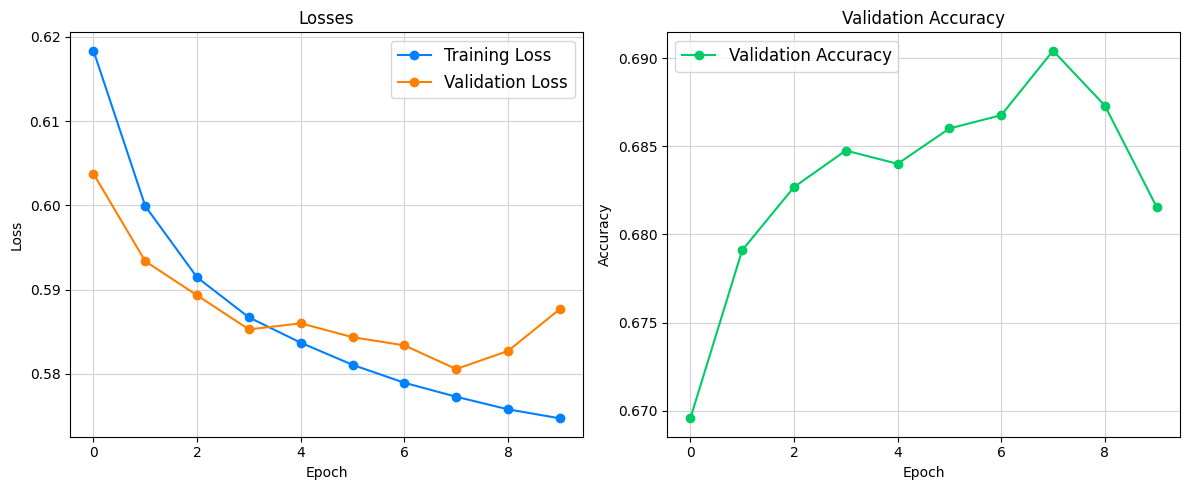

In [52]:
plot_results(training_losses_v2, val_losses_v2, val_accuracies_v2)

As we can see the results are way better than the version 1 of the model, as the **training** and **validation losses** are slightly converging towards each other, and the **validation** accuracy is increasing.

In [53]:
# Evaluate the model and get the metrics result
accuracy_v2, precision_v2, recall_v2, f1_score_v2, conf_matrix_v2 = evaluate_model(model_v2, validation_loader)

# Print the results
print(f"Validation Accuracy: {accuracy_v2:.4f}")
print(f"Validation Precision: {precision_v2:.4f}")
print(f"Validation Recall: {recall_v2:.4f}")
print(f"Validation F1 Score: {f1_score_v2:.4f}")

Started evaluation...
Evaluation Done! | Time elapsed: 7.966436386108398 seconds
Validation Accuracy: 0.6816
Validation Precision: 0.6874
Validation Recall: 0.6816
Validation F1 Score: 0.6790


#### Advanced Model
Up to now we have used a very simple network, with only 1 hidden layer. The next step is to upgrade our model and use a **deeper neural network** with more layers. We are going to use the following erchitecture: **4 hidden layers**, each one having **256, 128, 64, and 32 neurals**.

##### Model Initialization

In [54]:
import torch.nn as nn
import torch.nn.functional as F

class SentimentClassifier_V3(nn.Module):
    '''
    Advanced Model of the sentiment classifier project (Version 2).
    - 4 hidden layers
    - 256, 128, 64, and 32 neurals
    - Relu activation function
    '''
    def __init__(self, input_dim, output_dim):
        super(SentimentClassifier_V3, self).__init__()

        # Define the fully connected layers of the network
        self.fc1 = nn.Linear(input_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 32)
        self.fc5 = nn.Linear(32, output_dim)

    def forward(self, x):
        # Pass the input data through the fully connected layers and return the result
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        x = self.fc5(x)

        return x

##### Training the model
Let's traing this model using the same hyperparameters.

In [55]:
# Initialize a model of the second version of Sentiment Classifier
model_v3 = SentimentClassifier_V3(input_dim, output_dim).to(device)

# Redefine the hyperparameters
epochs = 10
learning_rate = 0.001
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_v3.parameters(), lr=learning_rate)

# Train the model using the same hyperparameters
train_losses_v3, val_losses_v3, val_accuracies_v3 = train_model(
    model_v3, train_loader, validation_loader, criterion, optimizer, device, epochs
)

Training Process Started. 
Training for 10 epochs...
Epoch [1/10] | Training Loss: 0.61377 | Validation Loss: 0.61420 | Validation Accuracy: 0.6512
Epoch [2/10] | Training Loss: 0.59110 | Validation Loss: 0.58456 | Validation Accuracy: 0.6856
Epoch [3/10] | Training Loss: 0.58074 | Validation Loss: 0.58286 | Validation Accuracy: 0.6858
Epoch [4/10] | Training Loss: 0.57501 | Validation Loss: 0.58517 | Validation Accuracy: 0.6825
Epoch [5/10] | Training Loss: 0.57006 | Validation Loss: 0.57722 | Validation Accuracy: 0.6885
Epoch [6/10] | Training Loss: 0.56504 | Validation Loss: 0.57966 | Validation Accuracy: 0.6849
Epoch [7/10] | Training Loss: 0.56008 | Validation Loss: 0.57908 | Validation Accuracy: 0.6892
Epoch [8/10] | Training Loss: 0.55522 | Validation Loss: 0.57529 | Validation Accuracy: 0.6944
Epoch [9/10] | Training Loss: 0.55020 | Validation Loss: 0.58223 | Validation Accuracy: 0.6893
Epoch [10/10] | Training Loss: 0.54615 | Validation Loss: 0.57723 | Validation Accuracy: 0.6

##### Plotting the results
Let's plot the model performance like before.

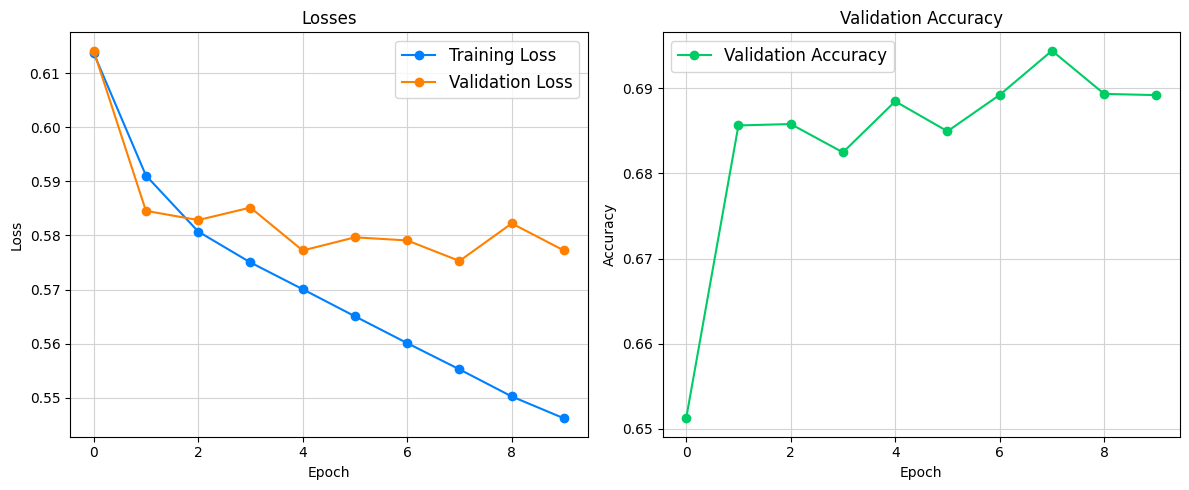

In [56]:
plot_results(train_losses_v3, val_losses_v3, val_accuracies_v3)

According to the results ontained we notice that the model's performance this time is actually worse than before. Specifically we can clearly see that the training and validation losses are not converging like before, but instead the validation loss starts to increase at the end. This is a big sign of **overfitting** and the possible reasons why this is happening are:
1. The model is too complex
2. The learning rate is too large
3. No reguralization is applied

The truth is that reguralization is indeed not applied to the current version of the model and that might cause the problem of overfitting. We will try to add some regularization and see the results we get.

#### Data Reguralization
We will define a model that uses reguralization techniques. Specifically we are going to use:
1. **50%** of dropout and
2. small ammount of weight decay

##### Model Definition
We start by defining out model

In [57]:
class SentimentClassifier_V4(nn.Module):
    '''
    Advanced Model of the sentiment classifier project that uses reguralization (Version 4).

    - 4 hidden layers
    - 256, 128, 64, and 32 neurals
    - Relu activation function
    - 50% dropout
    - small amount of weight decay
    '''
    def __init__(self, input_dim, output_dim):
        super(SentimentClassifier_V4, self).__init__()

        # Define the fully connected layers of the network
        self.fc1 = nn.Linear(input_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 32)
        self.fc5 = nn.Linear(32, output_dim)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        # Pass the input data through the fully connected layers and return the result
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = F.relu(self.fc3(x))
        x = self.dropout(x)
        x = F.relu(self.fc4(x))
        x = self.dropout(x)
        x = self.fc5(x)

        return x

##### Training the model with regularization
Next we train our model. We are going to define our optimizer with **weight_decay** this time. We will also increase the number of epochs.

In [58]:
# Define the model
model_v4 = SentimentClassifier_V4(input_dim, output_dim).to(device)

# Redefine the hyperparameters
epochs = 20
learning_rate = 0.001
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_v4.parameters(), lr=learning_rate, weight_decay=1e-5) # Add regularization

# Train the model
train_losses_v4, val_losses_v4, val_accuracies_v4 = train_model(
    model_v4, train_loader, validation_loader, criterion, optimizer, device, epochs
)

Training Process Started. 
Training for 20 epochs...
Epoch [1/20] | Training Loss: 0.63554 | Validation Loss: 0.60854 | Validation Accuracy: 0.6632
Epoch [3/20] | Training Loss: 0.60829 | Validation Loss: 0.59089 | Validation Accuracy: 0.6799
Epoch [5/20] | Training Loss: 0.60177 | Validation Loss: 0.59160 | Validation Accuracy: 0.6803
Epoch [7/20] | Training Loss: 0.59770 | Validation Loss: 0.58452 | Validation Accuracy: 0.6870
Epoch [9/20] | Training Loss: 0.59702 | Validation Loss: 0.59106 | Validation Accuracy: 0.6800
Epoch [11/20] | Training Loss: 0.59456 | Validation Loss: 0.58343 | Validation Accuracy: 0.6877
Epoch [13/20] | Training Loss: 0.59151 | Validation Loss: 0.58031 | Validation Accuracy: 0.6881
Epoch [15/20] | Training Loss: 0.59097 | Validation Loss: 0.58239 | Validation Accuracy: 0.6850
Epoch [17/20] | Training Loss: 0.58889 | Validation Loss: 0.58039 | Validation Accuracy: 0.6899
Epoch [19/20] | Training Loss: 0.58725 | Validation Loss: 0.58026 | Validation Accuracy:

##### Plotting the results
Let's plot our results

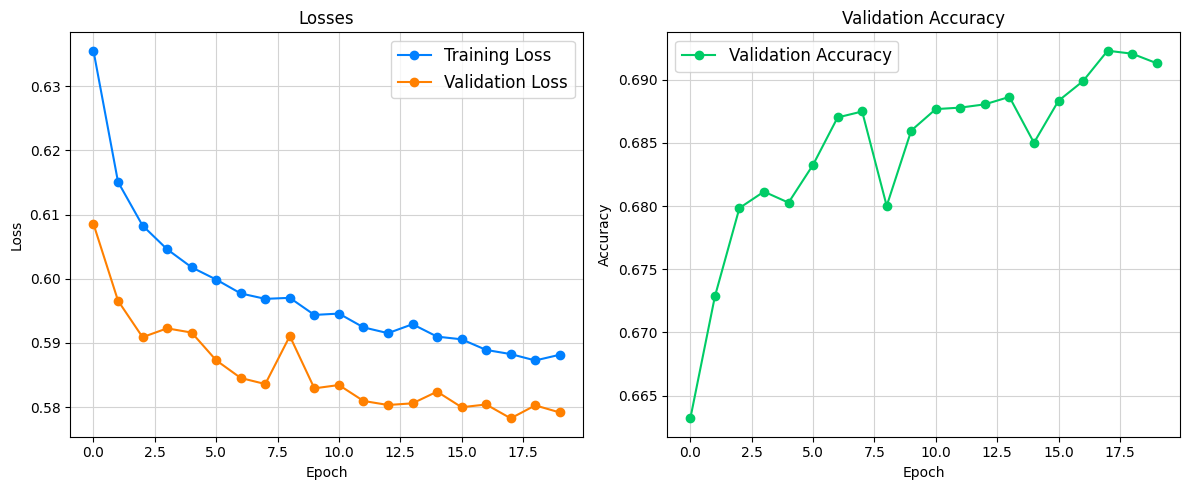

In [59]:
plot_results(train_losses_v4, val_losses_v4, val_accuracies_v4)

As we see the results obtained are better than the last version. The validation loss is deacreasing and the validation accuracy goes up.

In [60]:
accuracy_v4, precision_v4, recall_v4, f1_score_v4, conf_matrix_v4 = evaluate_model(model_v4, validation_loader)
print(f"Validation Accuracy: {accuracy_v4:.4f}")
print(f"Validation Precision: {precision_v4:.4f}")
print(f"Validation Recall: {recall_v4:.4f}")
print(f"Validation F1 Score: {f1_score_v4:.4f}")

Started evaluation...
Evaluation Done! | Time elapsed: 8.092294692993164 seconds
Validation Accuracy: 0.6913
Validation Precision: 0.6921
Validation Recall: 0.6913
Validation F1 Score: 0.6910


#### Updating Embeddings Count
Up to now we have experimented **50-dimension** representation of word embeddings. The next step in our progress is to experiment with different values of dimensions (50, 100, 200, 300) and check the results obtained.

In [61]:
dimensions = [50, 100, 200, 300]
dimensions_results = {}

# Experiment with different values of dimension representation of the data
for dim in dimensions:

    print(f'Training with {dim} as a dimension representation of data')

    # Load the glove embeddings located at the corrsponding path
    glove_path = f'{glove_folder}/glove.6B.{dim}d.txt'
    embeddings = load_glove(glove_path)

    # Construct Text Datasets
    ngram_range = (1, 1)
    train_dataset = TextDataset(
        train_df['Cleaned_text'].reset_index(drop=True),
        train_df['Label'].reset_index(drop=True),
        embeddings, dim, ngram_range=ngram_range
    )
    validation_dataset = TextDataset(
        val_df['Cleaned_text'].reset_index(drop=True),
        val_df['Label'].reset_index(drop=True),
        embeddings, dim, ngram_range=ngram_range
    )

    # Construct Dataloaders for the datasets
    train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
    validation_loader = DataLoader(validation_dataset, batch_size=256, shuffle=False)

    # Redefine the input and output dimensions of the network
    input_dim = dim * (ngram_range[1] - ngram_range[0] + 1)
    output_dim = len(set(train_df['Label']))

    # Define the model
    model = SentimentClassifier_V4(input_dim, output_dim).to(device)

    # Redefine the hyperparameters of the training process
    epochs = 20
    learning_rate = 0.001
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # Train the model
    training_losses, val_losses, val_accuracies = train_model(
        model, train_loader, validation_loader, criterion, optimizer, device, epochs
    )

    dimensions_results[dim] = (training_losses, val_losses, val_accuracies)

Training with 50 as a dimension representation of data
Training Process Started. 
Training for 20 epochs...
Epoch [1/20] | Training Loss: 0.63792 | Validation Loss: 0.60509 | Validation Accuracy: 0.6714
Epoch [3/20] | Training Loss: 0.60898 | Validation Loss: 0.59188 | Validation Accuracy: 0.6793
Epoch [5/20] | Training Loss: 0.60296 | Validation Loss: 0.58806 | Validation Accuracy: 0.6826
Epoch [7/20] | Training Loss: 0.59771 | Validation Loss: 0.58205 | Validation Accuracy: 0.6868
Epoch [9/20] | Training Loss: 0.59536 | Validation Loss: 0.58231 | Validation Accuracy: 0.6863
Epoch [11/20] | Training Loss: 0.59357 | Validation Loss: 0.58221 | Validation Accuracy: 0.6889
Epoch [13/20] | Training Loss: 0.59121 | Validation Loss: 0.57930 | Validation Accuracy: 0.6889
Epoch [15/20] | Training Loss: 0.59041 | Validation Loss: 0.57737 | Validation Accuracy: 0.6897
Epoch [17/20] | Training Loss: 0.58872 | Validation Loss: 0.57994 | Validation Accuracy: 0.6907
Epoch [19/20] | Training Loss: 0.

##### Plotting the results
Let's plot the results. We will first plot the training and validation losses.

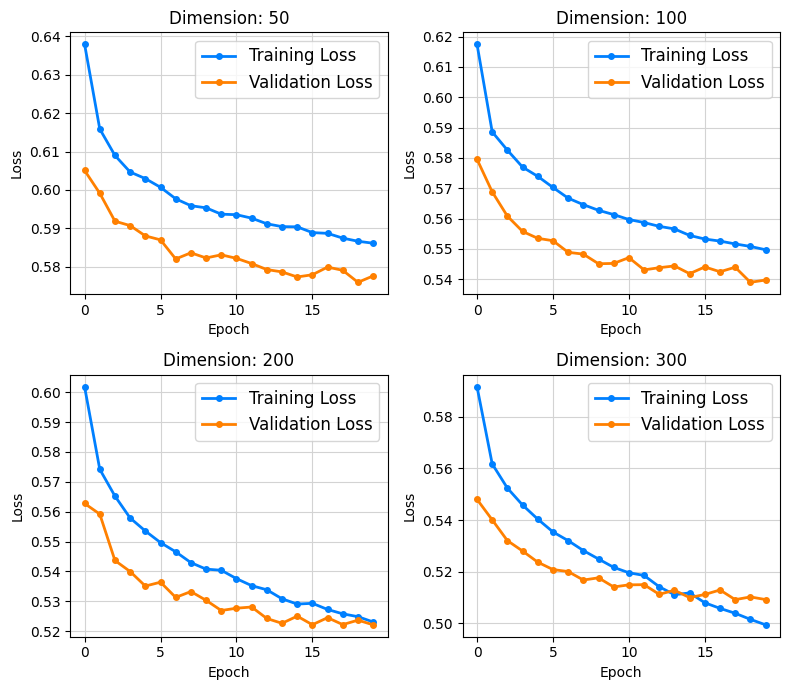

In [62]:
fig, axes = plt.subplots(2, 2, figsize=(8, 7))
fig.patch.set_facecolor(patch_background_color)

for i, dim in enumerate(dimensions):
    ax = axes[i // 2, i % 2]
    ax.set_facecolor(plot_background_color)
    ax.plot(dimensions_results[dim][0], '-o', markersize=4, linewidth=2, color='#0080FF', label='Training Loss')
    ax.plot(dimensions_results[dim][1], '-o', markersize=4, linewidth=2, color='#FF8000', label='Validation Loss')
    ax.set_title(f"Dimension: {dim}", color=text_color)
    ax.set_xlabel("Epoch", color=text_color)
    ax.set_ylabel("Loss", color=text_color)
    ax.tick_params(axis='both', colors=text_color)
    for spine in ax.spines.values():
        spine.set_edgecolor(text_color)
    ax.grid(color=plot_grid_color)
    ax.legend(loc='best', fontsize=12, labelcolor=text_color).get_frame().set_facecolor(patch_background_color)


plt.tight_layout()
plt.show()

And then the validation accuracies for every dimension.

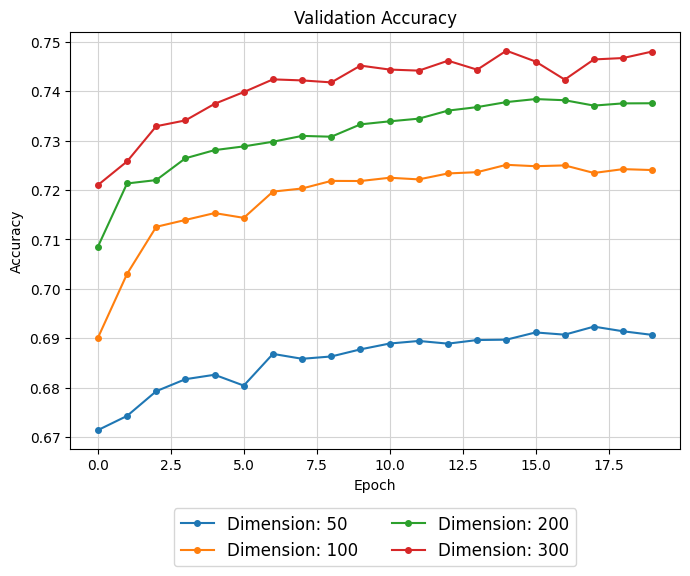

In [63]:
fig, ax = plt.subplots(1, 1, figsize=(7, 6))
fig.patch.set_facecolor(patch_background_color)
ax.set_facecolor(patch_background_color)

for i, dim in enumerate(dimensions):
    ax.plot(dimensions_results[dim][2], '-o', markersize=4, label=f"Dimension: {dim}")
    ax.set_title("Validation Accuracy", color=text_color)
    ax.set_xlabel("Epoch", color=text_color)
    ax.set_ylabel("Accuracy", color=text_color)
    ax.tick_params(axis='both', colors=text_color)
    for spine in ax.spines.values():
        spine.set_edgecolor(text_color)
    ax.grid(color=plot_grid_color)
    ax.legend(loc='lower center', fontsize=12, labelcolor=text_color).get_frame().set_facecolor(patch_background_color)
    legend = ax.legend(
        loc='lower center', bbox_to_anchor=(0.5, -0.3), 
        fontsize=12, labelcolor=text_color, ncol=2,
    )
    legend.get_frame().set_facecolor(patch_background_color)  # Match legend facecolor to theme

plt.tight_layout()
plt.show()

As we can see the **300-dimension** representation is much better than the others and that might occur due to the larger information it might has for the word embeddings. So we are going to use word embeddings in the 300-dimension representation from now on.

#### Batch Normalization
We will try to add some batch normalization to the layers of our network.

##### Model Definition
Let's start by defining the 5th version of our model.

In [64]:
class SentimentClassifier_V5(nn.Module):
    '''
    Advanced Model of the sentiment classifier project that uses batch normalization (Version 5).

    - 4 hidden layers
    - 256, 128, 64, and 32 neurals
    - Relu activation function
    - 50% dropout
    - small amount of weight decay
    - batch normalization
    '''

    def __init__(self, input_dim, output_dim):
        super(SentimentClassifier_V5, self).__init__()

        # Define the fully connected layers of the network
        self.fc1 = nn.Linear(input_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 32)
        self.fc5 = nn.Linear(32, output_dim)

        # Define dropout
        self.dropout = nn.Dropout(0.5)

        # Define batch normalizers
        self.bn1 = nn.BatchNorm1d(256)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(64)
        self.bn4 = nn.BatchNorm1d(32)
        self.bn5 = nn.BatchNorm1d(output_dim)

    def forward(self, x):
        # Pass the input data through the fully connected layers and return the result
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = F.relu(self.bn3(self.fc3(x)))
        x = self.dropout(x)
        x = F.relu(self.bn4(self.fc4(x)))
        x = self.dropout(x)
        x = self.bn5(self.fc5(x))

        return x

##### Training the model
Let's train the model

In [65]:
# Initialize the embeddings
glove_path = f'{glove_folder}/glove.6B.300d.txt' # Use the 300-dimension representation
embeddings = load_glove(glove_path)

# Define the input and output dimensions
input_dim = 300 * (ngram_range[1] - ngram_range[0] + 1)
output_dim = len(set(train_df['Label']))

# Construct the datasets
train_dataset = TextDataset(
    train_df['Cleaned_text'].reset_index(drop=True),
    train_df['Label'].reset_index(drop=True),
    embeddings, 300, ngram_range=ngram_range
)
validation_dataset = TextDataset(
    val_df['Cleaned_text'].reset_index(drop=True),
    val_df['Label'].reset_index(drop=True),
    embeddings, 300, ngram_range=ngram_range
)

# Construct the dataloaders
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=256, shuffle=False)

In [66]:
# Define the model
model_v5 = SentimentClassifier_V5(input_dim, output_dim).to(device)

# Redefine hyperparameters
epochs = 20
learning_rate = 0.001
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_v5.parameters(), lr=learning_rate, weight_decay=1e-5)

# Train the model
train_losses_v5, val_losses_v5, val_accuracies_v5 = train_model(
    model_v5, train_loader, validation_loader, criterion, optimizer, device, epochs
)

Training Process Started. 
Training for 20 epochs...
Epoch [1/20] | Training Loss: 0.61495 | Validation Loss: 0.54684 | Validation Accuracy: 0.7200
Epoch [3/20] | Training Loss: 0.55276 | Validation Loss: 0.53063 | Validation Accuracy: 0.7344
Epoch [5/20] | Training Loss: 0.54035 | Validation Loss: 0.52423 | Validation Accuracy: 0.7363
Epoch [7/20] | Training Loss: 0.53189 | Validation Loss: 0.51914 | Validation Accuracy: 0.7420
Epoch [9/20] | Training Loss: 0.52581 | Validation Loss: 0.51231 | Validation Accuracy: 0.7468
Epoch [11/20] | Training Loss: 0.51793 | Validation Loss: 0.50914 | Validation Accuracy: 0.7479
Epoch [13/20] | Training Loss: 0.51380 | Validation Loss: 0.50746 | Validation Accuracy: 0.7486
Epoch [15/20] | Training Loss: 0.50805 | Validation Loss: 0.50679 | Validation Accuracy: 0.7496
Epoch [17/20] | Training Loss: 0.50467 | Validation Loss: 0.50629 | Validation Accuracy: 0.7510
Epoch [19/20] | Training Loss: 0.50016 | Validation Loss: 0.50454 | Validation Accuracy:

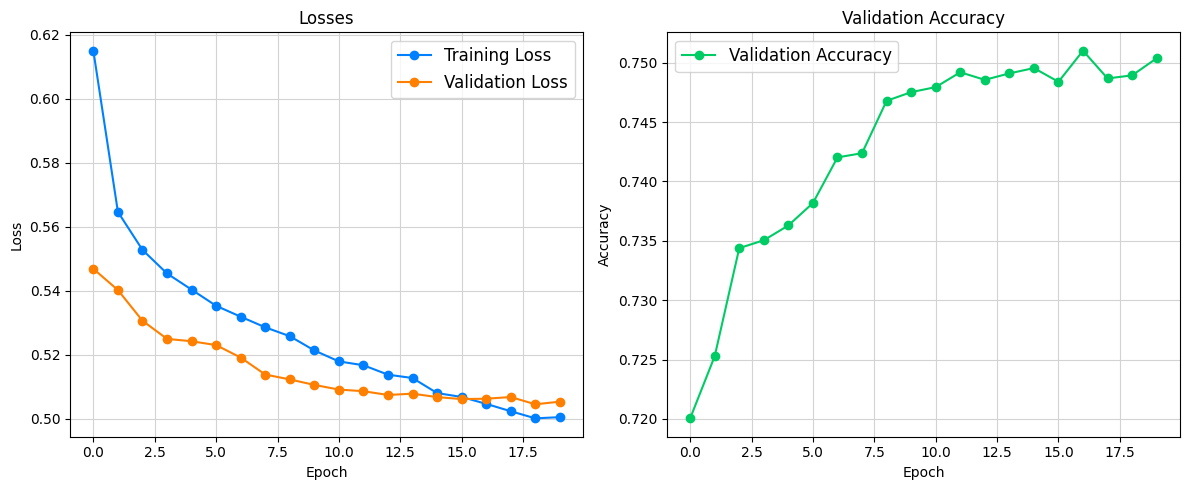

In [67]:
plot_results(train_losses_v5, val_losses_v5, val_accuracies_v5)

In [68]:
# Validate
accuracy_v5, precision_v5, recall_v5, f1_score_v5, conf_matrix_v5 = evaluate_model(model_v5, validation_loader)
print(f"Validation Accuracy: {accuracy_v5:.4f}")
print(f"Validation Precision: {precision_v5:.4f}")
print(f"Validation Recall: {recall_v5:.4f}")
print(f"Validation F1 Score: {f1_score_v5:.4f}")

Started evaluation...
Evaluation Done! | Time elapsed: 9.300119400024414 seconds
Validation Accuracy: 0.7504
Validation Precision: 0.7531
Validation Recall: 0.7504
Validation F1 Score: 0.7497


#### Learning Rate Scedulers
We will also try to experiment with learning rate scedulers. For this we are going to update our training function in order to use the scheduler.

In [69]:
@notify('Training Process Started. ', 'Training Process Done!')
def train_model(model, train_loader, validation_loader, criterion, optimizer, scheduler, device, epochs):
    ''' Train a given model with a learning rate scheduler '''
    print(f'Training for {epochs} epochs with a learning rate scheduler...')

    train_epoch_losses = []
    val_epoch_losses = []
    val_epoch_accuracies = []

    for epoch in range(epochs):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_accuracy = validate_one_epoch(model, validation_loader, criterion, device)

        train_epoch_losses.append(train_loss)
        val_epoch_losses.append(val_loss)
        val_epoch_accuracies.append(val_accuracy)

        # Step the scheduler
        scheduler.step(val_loss)

        if epoch == 0 or epoch == epochs - 1 or epoch % max(1, (epochs // 10)) == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Training Loss: {train_loss:.5f} ", end="")
            print(f"| Validation Loss: {val_loss:.5f} | Validation Accuracy: {val_accuracy:.4f}")

    return train_epoch_losses, val_epoch_losses, val_epoch_accuracies


##### Hyperparameters Redefinition
We will also have to redefine our hyperparameters and create our sceduler.

In [70]:
# Initialize model
model_v6 = SentimentClassifier_V5(input_dim, output_dim).to(device)

# Redefine hyperparameters
epochs = 20
learning_rate = 0.001
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_v6.parameters(), lr=learning_rate, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)

In [71]:
training_losses_v6, val_losses_v6, val_accuracies_v6 = train_model(
    model_v6, train_loader, validation_loader, criterion, optimizer, scheduler, device, epochs
)

Training Process Started. 
Training for 20 epochs with a learning rate scheduler...
Epoch [1/20] | Training Loss: 0.61960 | Validation Loss: 0.54625 | Validation Accuracy: 0.7213
Epoch [3/20] | Training Loss: 0.55371 | Validation Loss: 0.52910 | Validation Accuracy: 0.7343
Epoch [5/20] | Training Loss: 0.54165 | Validation Loss: 0.52590 | Validation Accuracy: 0.7366
Epoch [7/20] | Training Loss: 0.53204 | Validation Loss: 0.51782 | Validation Accuracy: 0.7405
Epoch [9/20] | Training Loss: 0.52642 | Validation Loss: 0.51440 | Validation Accuracy: 0.7434
Epoch [11/20] | Training Loss: 0.51945 | Validation Loss: 0.51053 | Validation Accuracy: 0.7465
Epoch [13/20] | Training Loss: 0.51406 | Validation Loss: 0.50694 | Validation Accuracy: 0.7484
Epoch [15/20] | Training Loss: 0.50933 | Validation Loss: 0.50734 | Validation Accuracy: 0.7472
Epoch [17/20] | Training Loss: 0.50508 | Validation Loss: 0.50668 | Validation Accuracy: 0.7490
Epoch [19/20] | Training Loss: 0.50093 | Validation Loss:

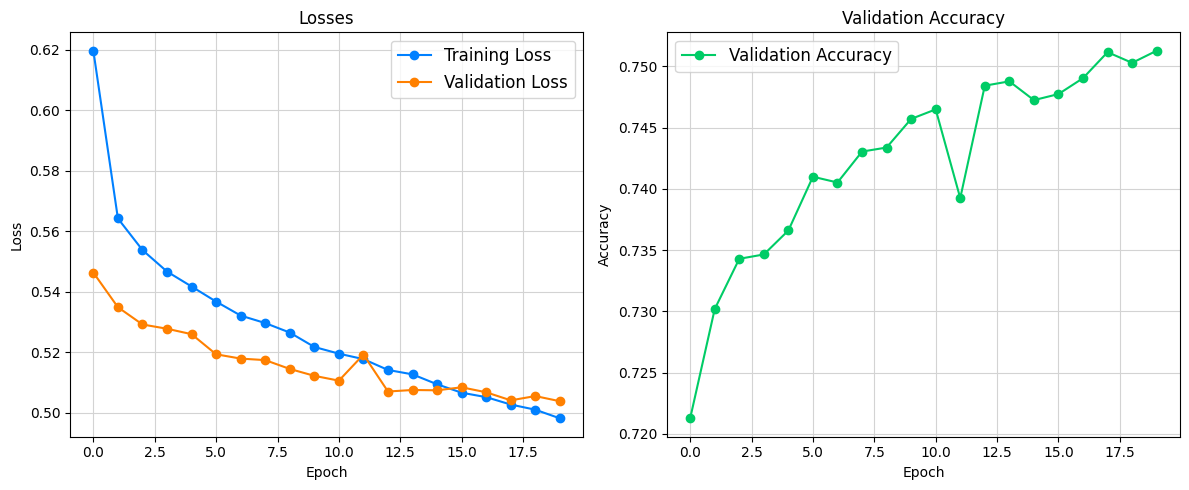

In [72]:
plot_results(training_losses_v6, val_losses_v6, val_accuracies_v6)

In [73]:
# Validate the model
accuracy_v6, precision_v6, recall_v6, f1_v6, conv_matrix_v6 = evaluate_model(model_v6, validation_loader)
print(f"Validation Accuracy: {accuracy_v6:.4f}")
print(f"Validation Precision: {precision_v6:.4f}")
print(f"Validation Recall: {recall_v6:.4f}")
print(f"Validation F1 Score: {f1_v6:.4f}")

Started evaluation...
Evaluation Done! | Time elapsed: 9.40346908569336 seconds
Validation Accuracy: 0.7513
Validation Precision: 0.7513
Validation Recall: 0.7513
Validation F1 Score: 0.7513


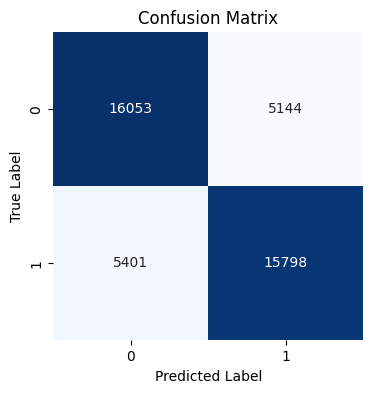

In [74]:
# Plot the confusion matrix
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
fig.patch.set_facecolor(patch_background_color)
ax.set_facecolor(patch_background_color)
plot_confusion_matrix(ax, conv_matrix_v6, classes=unique_labels)
plt.show()

### Hyperparameter Tuning
Next we are going to experiment with the hyperparameters we are using in this model. We have already experimented with the number of epochs and we figured out that 20 is the best option for now.

#### Optimizer
We will start by training for different optimizers.

In [75]:
# Define a dictionary of optimizers for the model
optimizers = {
    'SGD': torch.optim.SGD,
    'Adam': torch.optim.Adam,
    'RMSprop': torch.optim.RMSprop,
    'Adagrad': torch.optim.Adagrad,
    'AdamW': torch.optim.AdamW
}

In [76]:
def train_model_with_optimizer(model, train_loader, validation_loader, criterion, optimizer_class, device, epochs):
    ''' Train a given model with a specific optimizer '''
    print(f'Training for {epochs} epochs with {optimizer_class.__name__} optimizer...')

    train_epoch_losses = []
    val_epoch_losses = []
    val_epoch_accuracies = []

    # Initialize the optimizer
    optimizer = optimizer_class(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_accuracy = validate_one_epoch(model, validation_loader, criterion, device)

        train_epoch_losses.append(train_loss)
        val_epoch_losses.append(val_loss)
        val_epoch_accuracies.append(val_accuracy)

        if epoch == 0 or epoch == epochs - 1 or epoch % max(1, (epochs // 10)) == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Training Loss: {train_loss:.5f} ", end="")
            print(f"| Validation Loss: {val_loss:.5f} | Validation Accuracy: {val_accuracy:.4f}")

    return train_epoch_losses, val_epoch_losses, val_epoch_accuracies

In [77]:
optimizer_results = {}
for optimizer_name, optimizer_class in optimizers.items():
    # Initialize the model
    model = SentimentClassifier_V5(input_dim, output_dim).to(device)
    optimizer_results[optimizer_name] = {}

    # Redefine hyperparameters
    epochs = 20
    criterion = nn.CrossEntropyLoss()
    optimizer = optimizer_class(model.parameters(), lr=0.001, weight_decay=1e-5)

    # Train the model
    training_losses, val_losses, val_accuracies = train_model_with_optimizer(
        model, train_loader, validation_loader, criterion, optimizer_class, device, epochs
    )
    optimizer_results[optimizer_name]['training_results'] = (training_losses, val_losses, val_accuracies)

    # Evaluate the model
    accuracy, precision, recall, f1, conf_matrix = evaluate_model(model, validation_loader)
    optimizer_results[optimizer_name]['evaluation_results'] = (accuracy, precision, recall, f1, conf_matrix)

Training for 20 epochs with SGD optimizer...
Epoch [1/20] | Training Loss: 0.83772 | Validation Loss: 0.69046 | Validation Accuracy: 0.5317
Epoch [3/20] | Training Loss: 0.71250 | Validation Loss: 0.68359 | Validation Accuracy: 0.5576
Epoch [5/20] | Training Loss: 0.69345 | Validation Loss: 0.68374 | Validation Accuracy: 0.5566
Epoch [7/20] | Training Loss: 0.68874 | Validation Loss: 0.68468 | Validation Accuracy: 0.5453
Epoch [9/20] | Training Loss: 0.68678 | Validation Loss: 0.68462 | Validation Accuracy: 0.5430
Epoch [11/20] | Training Loss: 0.68563 | Validation Loss: 0.68307 | Validation Accuracy: 0.5482
Epoch [13/20] | Training Loss: 0.68385 | Validation Loss: 0.68190 | Validation Accuracy: 0.5492
Epoch [15/20] | Training Loss: 0.68197 | Validation Loss: 0.67923 | Validation Accuracy: 0.5587
Epoch [17/20] | Training Loss: 0.68054 | Validation Loss: 0.67719 | Validation Accuracy: 0.5646
Epoch [19/20] | Training Loss: 0.67870 | Validation Loss: 0.67510 | Validation Accuracy: 0.5668


Let's plot the results obtained by the optimizers training

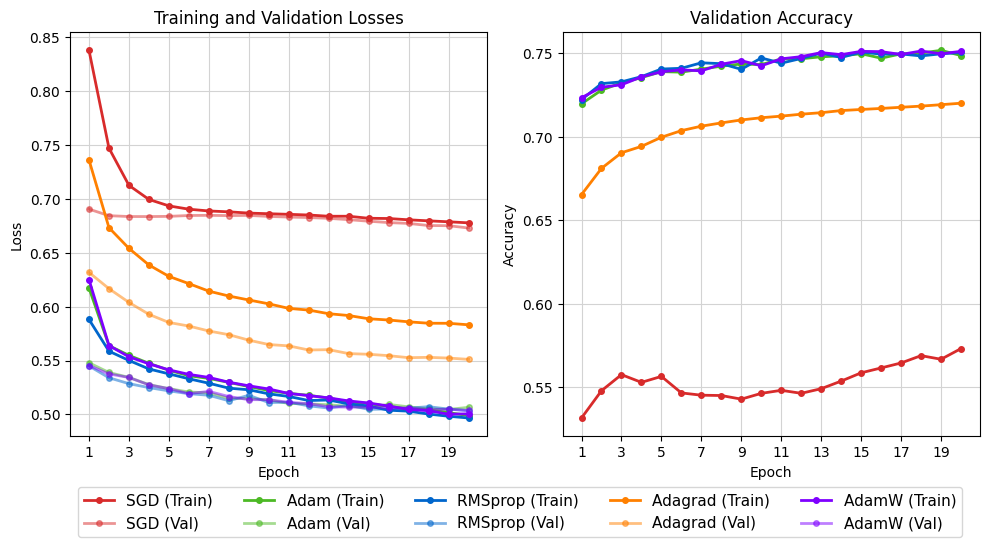

In [78]:
# Plot the training results (training & validation loss) and validation accuracy for each optimizer
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.patch.set_facecolor(patch_background_color)

# Define the base colors for each optimizer
base_colors = {
    'SGD': '#D82B2B',  # Red
    'Adam': '#4CB925',  # Green
    'RMSprop': '#0066CC',  # Blue
    'Adagrad': '#FF8000',  # Orange
    'AdamW': '#7F00FF'  # Purple
}

# Plot the training and validation losses
axes[0].set_facecolor(plot_background_color)
for optimizer_name, results in optimizer_results.items():
    train_losses, val_losses, _ = results['training_results']
    train_color = base_colors[optimizer_name]  # Brighter color for training
    val_color = base_colors[optimizer_name] + '80'  # Darker (semi-transparent) color for validation
    axes[0].plot(train_losses, '-o', markersize=4, linewidth=2, color=train_color, label=f'{optimizer_name} (Train)')
    axes[0].plot(val_losses, '-o', markersize=4, linewidth=2, color=val_color, label=f'{optimizer_name} (Val)')

axes[0].set_title("Training and Validation Losses", color=text_color)
axes[0].set_xlabel("Epoch", color=text_color)
axes[0].set_ylabel("Loss", color=text_color)
axes[0].tick_params(axis='both', colors=text_color)
axes[0].grid(color=plot_grid_color)
axes[0].set_xticks(range(0, len(train_losses), 2))  # Adjust x-ticks with step size 2
axes[0].set_xticklabels(range(1, len(train_losses) + 1, 2))  # Start x-ticks from 1
for spine in axes[0].spines.values():
    spine.set_edgecolor(text_color)

# Plot the validation accuracies
axes[1].set_facecolor(plot_background_color)
for optimizer_name, results in optimizer_results.items():
    _, _, val_accuracies = results['training_results']
    accuracy_color = base_colors[optimizer_name]
    axes[1].plot(val_accuracies, '-o', markersize=4, linewidth=2, color=accuracy_color, label=optimizer_name)

axes[1].set_title("Validation Accuracy", color=text_color)
axes[1].set_xlabel("Epoch", color=text_color)
axes[1].set_ylabel("Accuracy", color=text_color)
axes[1].tick_params(axis='both', colors=text_color)
axes[1].grid(color=plot_grid_color)
axes[1].set_xticks(range(0, len(val_accuracies), 2))  # Adjust x-ticks with step size 2
axes[1].set_xticklabels(range(1, len(val_accuracies) + 1, 2))  # Start x-ticks from 1
for spine in axes[1].spines.values():
    spine.set_edgecolor(text_color)

# Add a single legend for both subplots
handles, labels = axes[0].get_legend_handles_labels()
legend = fig.legend(
    handles, labels, loc='lower center', bbox_to_anchor=(0.525, -0.1), 
    ncol=len(base_colors), fontsize=11, labelcolor=text_color
)
legend.get_frame().set_facecolor(patch_background_color)  # Match legend facecolor to theme

plt.tight_layout()
plt.show()

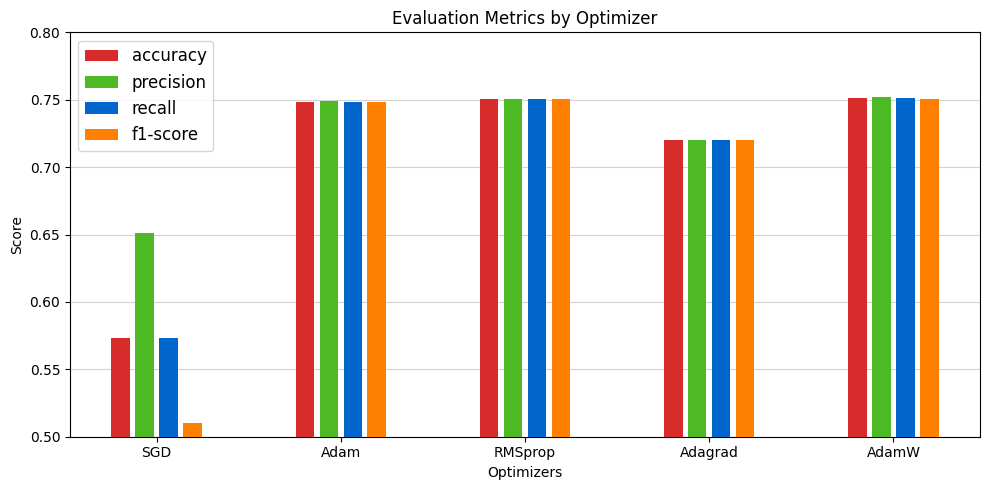

In [79]:
# Plot the evaluation results (accuracy, precision, recall, f1-score) for each optimizer
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
fig.patch.set_facecolor(patch_background_color)
ax.set_facecolor(plot_background_color)

# Define the metrics to plot
metrics = ['accuracy', 'precision', 'recall', 'f1-score']
metric_colors = {
    'accuracy': '#D82B2B',  # Red
    'precision': '#4CB925',  # Green
    'recall': '#0066CC',  # Blue
    'f1-score': '#FF8000'  # Orange
}

# Prepare data for the bar plot
bar_width = 0.10  # Reduced bar width for thinner bars
gap = 0.03  # Gap between groups of bars
x = range(len(optimizer_results))
for i, metric in enumerate(metrics):
    metric_values = [
        results['evaluation_results'][i] for optimizer_name, results in optimizer_results.items()
    ]
    ax.bar(
        [pos + i * (bar_width + gap) for pos in x],  # Add gap between groups
        metric_values,
        bar_width,
        label=metric,
        color=metric_colors[metric],
        zorder=3  # Ensure bars are in front of the grid
    )

# Customize the plot
ax.set_title("Evaluation Metrics by Optimizer", color=text_color)
ax.set_ylim(0.5, 0.8)
ax.set_xlabel("Optimizers", color=text_color)
ax.set_ylabel("Score", color=text_color)
ax.set_xticks([pos + (len(metrics) - 1) * (bar_width + gap) / 2 for pos in x])
ax.set_xticklabels(optimizer_results.keys(), color=text_color)
ax.tick_params(axis='both', colors=text_color)
ax.grid(color=plot_grid_color, axis='y', zorder=0)  # Ensure grid is behind the bars
for spine in ax.spines.values():
    spine.set_edgecolor(text_color)

# Add a legend with adjusted font size
ax.legend(loc='best', fontsize=12, labelcolor=text_color).get_frame().set_facecolor(patch_background_color)

plt.tight_layout()
plt.show()

In [80]:
# Create a DataFrame to store the metrics results
metrics_df = pd.DataFrame({
    'Optimizer': list(optimizer_results.keys()),
    'Accuracy': [results['evaluation_results'][0] for results in optimizer_results.values()],
    'Precision': [results['evaluation_results'][1] for results in optimizer_results.values()],
    'Recall': [results['evaluation_results'][2] for results in optimizer_results.values()],
    'F1 Score': [results['evaluation_results'][3] for results in optimizer_results.values()]
})

metrics_df

,Optimizer,Accuracy,Precision,Recall,F1 Score
0,SGD,0.573214,0.650925,0.573214,0.510180
1,Adam,0.748608,0.748732,0.748608,0.748577
2,RMSprop,0.750448,0.750526,0.750448,0.750429
3,Adagrad,0.720092,0.720396,0.720092,0.719995
4,AdamW,0.751132,0.752077,0.751132,0.750899


#### Loss Function
Next we are going to experiment with different loss functions. We are currently using the **Cross Entropy** loss function. Let's check what results the other loss functions produce.

In [81]:
# Define a dictionary of loss functions for the model
loss_functions = {
    'CrossEntropyLoss': nn.CrossEntropyLoss,
    'MSELoss': nn.MSELoss,
    'BCEWithLogitsLoss': nn.BCELoss
}

In [82]:
class SentimentClassifier_V6(nn.Module):
    '''
    Advanced Model of the sentiment classifier project that uses batch normalization (Version 6).

    - 4 hidden layers
    - 256, 128, 64, and 32 neurals
    - Relu activation function
    - 50% dropout
    - small amount of weight decay
    - batch normalization
    - 1 sigmoid output neuron
    '''

    def __init__(self, input_dim):
        super(SentimentClassifier_V6, self).__init__()

        # Define the fully connected layers of the network
        self.fc1 = nn.Linear(input_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 32)
        self.fc5 = nn.Linear(32, 1)

        self.dropout = nn.Dropout(0.5)

        self.bn1 = nn.BatchNorm1d(256)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(64)
        self.bn4 = nn.BatchNorm1d(32)
        self.bn5 = nn.BatchNorm1d(1)
        
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Pass the input data through the fully connected layers and return the result
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = F.relu(self.bn3(self.fc3(x)))
        x = self.dropout(x)
        x = F.relu(self.bn4(self.fc4(x)))
        x = self.dropout(x)
        x = self.bn5(self.fc5(x))
        x = self.sigmoid(x)

        return x

In [83]:
def train_one_epoch_v2(model, train_loader, criterion, optimizer, device):
    ''' Trains a given model for one epoch '''

    # Set the model to training mode and initialize the batch losses
    model.train()
    batch_losses = []

    # For every batch in the dataloader train the model
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device).float().unsqueeze(1)
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        batch_losses.append(loss.item())

        # Upgrade the weights of the network using backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Compute the average loss of the model and return it
    avg_loss = sum(batch_losses) / len(batch_losses)
    return avg_loss

In [84]:
def validate_one_epoch_v2(model, validation_loader, criterion, device):
    ''' Validates the model for one epoch '''

    # Set the model to evaluation mode and initialize the validation losses
    model.eval()
    val_losses = []
    correct, total = 0, 0

    # For every batch in the dataloader validate the model (keep its loss and accuracy)
    with torch.no_grad():
        for X_val, y_val in validation_loader:
            X_val, y_val = X_val.to(device), y_val.to(device).float().unsqueeze(1)
            y_val_pred = model(X_val)
            val_loss = criterion(y_val_pred, y_val)
            val_losses.append(val_loss.item())

            predicted = (y_val_pred >= 0.5).long()
            correct += (predicted == y_val.long()).sum().item()
            total += y_val.size(0)

    # Compute the average loss and the accuracy and return them
    avg_loss = sum(val_losses) / len(val_losses)
    accuracy = correct / total
    return avg_loss, accuracy

In [85]:
@notify('Training Process Started. ', 'Training Process Done!')
def train_model_v2(model, train_loader, validation_loader, criterion, optimizer, scheduler, device, epochs):
    ''' Train a given model with a learning rate scheduler '''
    print(f'Training for {epochs} epochs with a learning rate scheduler...')

    train_epoch_losses = []
    val_epoch_losses = []
    val_epoch_accuracies = []

    for epoch in range(epochs):
        train_loss = train_one_epoch_v2(model, train_loader, criterion, optimizer, device)
        val_loss, val_accuracy = validate_one_epoch_v2(model, validation_loader, criterion, device)

        train_epoch_losses.append(train_loss)
        val_epoch_losses.append(val_loss)
        val_epoch_accuracies.append(val_accuracy)

        # Step the scheduler
        scheduler.step(val_loss)

        if epoch == 0 or epoch == epochs - 1 or epoch % max(1, (epochs // 10)) == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Training Loss: {train_loss:.5f} ", end="")
            print(f"| Validation Loss: {val_loss:.5f} | Validation Accuracy: {val_accuracy:.4f}")

    return train_epoch_losses, val_epoch_losses, val_epoch_accuracies


In [86]:
# Train the model with different loss functions
loss_function_results = {}

for loss_name, loss_class in loss_functions.items():
    print(f'Training with {loss_name} loss function')
    if loss_name == 'CrossEntropyLoss':
        # Initialize the model
        model = SentimentClassifier_V5(input_dim, output_dim).to(device)
        loss_function_results[loss_name] = {}

        # Redefine hyperparameters
        epochs = 20
        criterion = loss_class()
        optimizer = torch.optim.RMSprop(model.parameters(), lr=0.001, weight_decay=1e-5)  # Use the best optimizer
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)

        # Train the model
        training_losses, val_losses, val_accuracies = train_model(
            model, train_loader, validation_loader, criterion, optimizer, scheduler, device, epochs
        )
    else:
        # Initialize the model
        model = SentimentClassifier_V6(input_dim).to(device)
        loss_function_results[loss_name] = {}

        # Redefine hyperparameters
        epochs = 20
        criterion = loss_class()
        optimizer = torch.optim.RMSprop(model.parameters(), lr=0.001, weight_decay=1e-5)  # Use the best optimizer
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)

        # Train the model
        training_losses, val_losses, val_accuracies = train_model_v2(
            model, train_loader, validation_loader, criterion, optimizer, scheduler, device, epochs
        )

    loss_function_results[loss_name]['training_results'] = (training_losses, val_losses, val_accuracies)

    # Evaluate the model
    accuracy, precision, recall, f1, conf_matrix = evaluate_model(model, validation_loader)
    loss_function_results[loss_name]['evaluation_results'] = (accuracy, precision, recall, f1, conf_matrix)

Training with CrossEntropyLoss loss function
Training Process Started. 
Training for 20 epochs with a learning rate scheduler...
Epoch [1/20] | Training Loss: 0.59183 | Validation Loss: 0.54614 | Validation Accuracy: 0.7213
Epoch [3/20] | Training Loss: 0.55047 | Validation Loss: 0.52952 | Validation Accuracy: 0.7337
Epoch [5/20] | Training Loss: 0.53844 | Validation Loss: 0.52374 | Validation Accuracy: 0.7391
Epoch [7/20] | Training Loss: 0.52851 | Validation Loss: 0.51655 | Validation Accuracy: 0.7429
Epoch [9/20] | Training Loss: 0.52288 | Validation Loss: 0.51604 | Validation Accuracy: 0.7407
Epoch [11/20] | Training Loss: 0.51722 | Validation Loss: 0.51027 | Validation Accuracy: 0.7489
Epoch [13/20] | Training Loss: 0.51143 | Validation Loss: 0.50656 | Validation Accuracy: 0.7485
Epoch [15/20] | Training Loss: 0.50739 | Validation Loss: 0.50832 | Validation Accuracy: 0.7491
Epoch [17/20] | Training Loss: 0.50431 | Validation Loss: 0.50437 | Validation Accuracy: 0.7506
Epoch [19/20

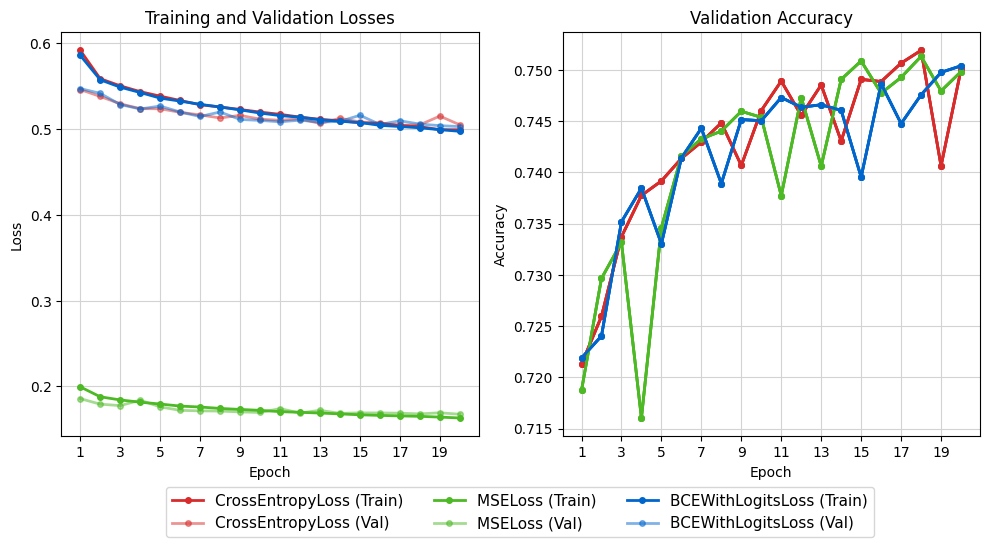

In [87]:
# Plot the training results (training & validation loss) and validation accuracy for each loss function
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.patch.set_facecolor(patch_background_color)
# Define the base colors for each loss function
base_colors = {
    'CrossEntropyLoss': '#D82B2B',  # Red
    'MSELoss': '#4CB925',  # Green
    'BCEWithLogitsLoss': '#0066CC'  # Blue
}
# Plot the training and validation losses
axes[0].set_facecolor(plot_background_color)
for loss_name, results in loss_function_results.items():
    train_losses, val_losses, _ = results['training_results']
    train_color = base_colors[loss_name]  # Brighter color for training
    val_color = base_colors[loss_name] + '80'  # Darker (semi-transparent) color for validation
    axes[0].plot(train_losses, '-o', markersize=4, linewidth=2, color=train_color, label=f'{loss_name} (Train)')
    axes[0].plot(val_losses, '-o', markersize=4, linewidth=2, color=val_color, label=f'{loss_name} (Val)')
    axes[0].set_title("Training and Validation Losses", color=text_color)
    axes[0].set_xlabel("Epoch", color=text_color)
    axes[0].set_ylabel("Loss", color=text_color)
    axes[0].tick_params(axis='both', colors=text_color)
    axes[0].grid(color=plot_grid_color)
    axes[0].set_xticks(range(0, len(train_losses), 2))  # Adjust x-ticks with step size 2
    axes[0].set_xticklabels(range(1, len(train_losses) + 1, 2))  # Start x-ticks from 1
    for spine in axes[0].spines.values():
        spine.set_edgecolor(text_color)

    # Plot the validation accuracies
    axes[1].set_facecolor(plot_background_color)
    for loss_name, results in loss_function_results.items():
        _, _, val_accuracies = results['training_results']
        accuracy_color = base_colors[loss_name]
        axes[1].plot(val_accuracies, '-o', markersize=4, linewidth=2, color=accuracy_color, label=loss_name)
        axes[1].set_title("Validation Accuracy", color=text_color)
        axes[1].set_xlabel("Epoch", color=text_color)
        axes[1].set_ylabel("Accuracy", color=text_color)
        axes[1].tick_params(axis='both', colors=text_color)
        axes[1].grid(color=plot_grid_color)
        axes[1].set_xticks(range(0, len(val_accuracies), 2))  # Adjust x-ticks with step size 2
        axes[1].set_xticklabels(range(1, len(val_accuracies) + 1, 2))  # Start x-ticks from 1
        for spine in axes[1].spines.values():
            spine.set_edgecolor(text_color)

# Add a single legend for both subplots
handles, labels = axes[0].get_legend_handles_labels()
legend = fig.legend(
    handles, labels, loc='lower center', bbox_to_anchor=(0.525, -0.1), 
    ncol=len(base_colors), fontsize=11, labelcolor=text_color
)
legend.get_frame().set_facecolor(patch_background_color)  # Match legend facecolor to theme
plt.tight_layout()
plt.show()

In [88]:
# Print the evaluation results for each loss function
for loss_name, results in loss_function_results.items():
    accuracy, precision, recall, f1, conf_matrix = results['evaluation_results']
    print(f"Loss Function: {loss_name}")
    print(f"Validation Accuracy: {accuracy:.4f}")
    print(f"Validation Precision: {precision:.4f}")
    print(f"Validation Recall: {recall:.4f}")
    print(f"Validation F1 Score: {f1:.4f}\n")

Loss Function: CrossEntropyLoss
Validation Accuracy: 0.7500
Validation Precision: 0.7509
Validation Recall: 0.7500
Validation F1 Score: 0.7498

Loss Function: MSELoss
Validation Accuracy: 0.5000
Validation Precision: 0.2500
Validation Recall: 0.5000
Validation F1 Score: 0.3333

Loss Function: BCEWithLogitsLoss
Validation Accuracy: 0.5000
Validation Precision: 0.2500
Validation Recall: 0.5000
Validation F1 Score: 0.3333



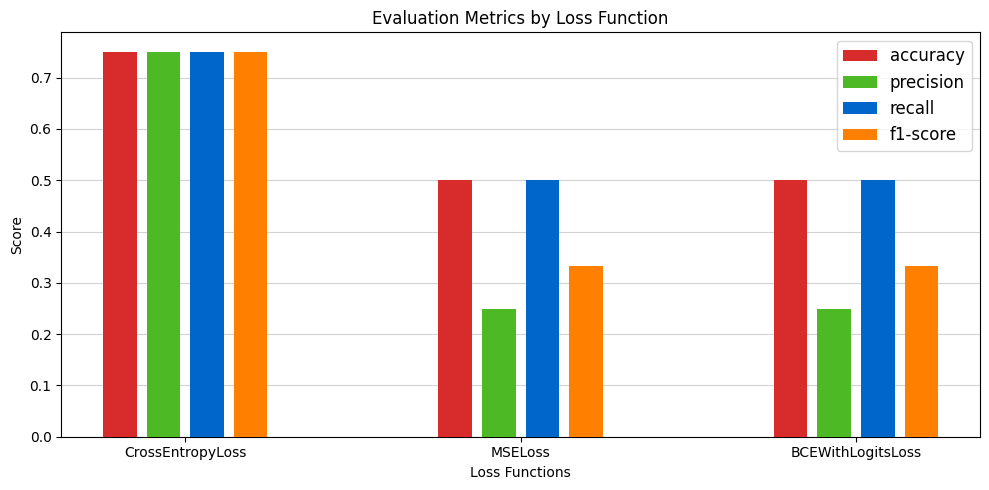

In [89]:
# Plot the evaluation results (accuracy, precision, recall, f1-score) for each loss function
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
fig.patch.set_facecolor(patch_background_color)
ax.set_facecolor(plot_background_color)

# Define the metrics to plot
metrics = ['accuracy', 'precision', 'recall', 'f1-score']
metric_colors = {
    'accuracy': '#D82B2B',  # Red
    'precision': '#4CB925',  # Green
    'recall': '#0066CC',  # Blue
    'f1-score': '#FF8000'  # Orange
}

# Prepare data for the bar plot
bar_width = 0.10  # Reduced bar width for thinner bars
gap = 0.03  # Gap between groups of bars
x = range(len(loss_function_results))

for i, metric in enumerate(metrics):
    metric_values = [
        results['evaluation_results'][i] for loss_name, results in loss_function_results.items()
    ]
    ax.bar(
        [pos + i * (bar_width + gap) for pos in x],  # Add gap between groups
        metric_values,
        bar_width,
        label=metric,
        color=metric_colors[metric],
        zorder=3  # Ensure bars are in front of the grid
    )

# Customize the plot
ax.set_title("Evaluation Metrics by Loss Function", color=text_color)
# ax.set_ylim(0.5, 0.8)
ax.set_xlabel("Loss Functions", color=text_color)
ax.set_ylabel("Score", color=text_color)
ax.set_xticks([pos + (len(metrics) - 1) * (bar_width + gap) / 2 for pos in x])
ax.set_xticklabels(loss_function_results.keys(), color=text_color)
ax.tick_params(axis='both', colors=text_color)
ax.grid(color=plot_grid_color, axis='y', zorder=0)  # Ensure grid is behind the bars
for spine in ax.spines.values():
    spine.set_edgecolor(text_color)

# Add a legend with adjusted font size
ax.legend(loc='best', fontsize=12, labelcolor=text_color).get_frame().set_facecolor(patch_background_color)
plt.tight_layout()
plt.show()

#### Using optuna
Next we are going to test the rest hyperparameters with the help of optuna library. Optuna is a library that helps us test multiple hyperparameters on a model very easy.

In [90]:
class SentimentClassifier_V7(nn.Module):
    def __init__(self, input_dim, num_layers, neurons_per_layer, dropout_rate):
        super(SentimentClassifier_V7, self).__init__()

        # Initialize the list of layers of the model
        layers = []
        prev_dim = input_dim

        # Construct the model architecture with the specified number of layers and neurons
        for _ in range(num_layers):
            layers.append(nn.Linear(prev_dim, neurons_per_layer))
            layers.append(nn.BatchNorm1d(neurons_per_layer))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_dim = neurons_per_layer

        # Add the final output layer with 2 neurons for binary classification
        layers.append(nn.Linear(prev_dim, 2))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

In [91]:
def objective(trial):
    ''' Objective function for Optuna optimization '''

    # Define the hyperparameters of the model to be optimized
    num_layers = trial.suggest_int('num_layers', 1, 5)
    neurons_per_layer = trial.suggest_int('neurons_per_layer', 32, 512, step=32)
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5, step=0.05)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)

    # Define the model and train it
    model = SentimentClassifier_V7(input_dim, num_layers, neurons_per_layer, dropout_rate).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)

    # Construct the dataloaders of the datasets
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)

    # Train the model
    _, _, _ = train_model(
        model, train_loader, validation_loader, criterion, optimizer, scheduler, device, epochs=20
    )

    # Evaluate the model
    accuracy, _, _, _, _ = evaluate_model(model, validation_loader)

    return accuracy

In [92]:
import optuna

# Create a study object and optimize the objective function
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=5)

# Print the best trial of the study optimization 
trial = study.best_trial
print(f"Best trial: {trial.number}")
print(f"Values: {trial.values}")
print(f"Params: {trial.params}")

[I 2025-05-06 00:13:17,090] A new study created in memory with name: no-name-cced616a-7141-4797-9fb8-87372890345f


Training Process Started. 
Training for 20 epochs with a learning rate scheduler...
Epoch [1/20] | Training Loss: 0.56429 | Validation Loss: 0.54318 | Validation Accuracy: 0.7255
Epoch [3/20] | Training Loss: 0.54099 | Validation Loss: 0.53351 | Validation Accuracy: 0.7326
Epoch [5/20] | Training Loss: 0.53280 | Validation Loss: 0.53093 | Validation Accuracy: 0.7365
Epoch [7/20] | Training Loss: 0.52887 | Validation Loss: 0.52710 | Validation Accuracy: 0.7392
Epoch [9/20] | Training Loss: 0.52562 | Validation Loss: 0.52600 | Validation Accuracy: 0.7419
Epoch [11/20] | Training Loss: 0.52406 | Validation Loss: 0.52776 | Validation Accuracy: 0.7372
Epoch [13/20] | Training Loss: 0.52144 | Validation Loss: 0.52236 | Validation Accuracy: 0.7425
Epoch [15/20] | Training Loss: 0.51952 | Validation Loss: 0.52753 | Validation Accuracy: 0.7380
Epoch [17/20] | Training Loss: 0.51777 | Validation Loss: 0.52312 | Validation Accuracy: 0.7444
Epoch [19/20] | Training Loss: 0.51709 | Validation Loss:

[I 2025-05-06 00:28:50,307] Trial 0 finished with value: 0.7434427776205302 and parameters: {'num_layers': 1, 'neurons_per_layer': 32, 'dropout_rate': 0.1, 'learning_rate': 0.0006125103440014455, 'batch_size': 64, 'weight_decay': 1.7666099147686805e-05}. Best is trial 0 with value: 0.7434427776205302.


Evaluation Done! | Time elapsed: 9.821953535079956 seconds
Training Process Started. 
Training for 20 epochs with a learning rate scheduler...
Epoch [1/20] | Training Loss: 0.59508 | Validation Loss: 0.56954 | Validation Accuracy: 0.6991
Epoch [3/20] | Training Loss: 0.57472 | Validation Loss: 0.56307 | Validation Accuracy: 0.7151
Epoch [5/20] | Training Loss: 0.57373 | Validation Loss: 0.56338 | Validation Accuracy: 0.7156
Epoch [7/20] | Training Loss: 0.57272 | Validation Loss: 0.56556 | Validation Accuracy: 0.7104
Epoch [9/20] | Training Loss: 0.57319 | Validation Loss: 0.55388 | Validation Accuracy: 0.7172
Epoch [11/20] | Training Loss: 0.57327 | Validation Loss: 0.55568 | Validation Accuracy: 0.7125
Epoch [13/20] | Training Loss: 0.57420 | Validation Loss: 0.56521 | Validation Accuracy: 0.7105
Epoch [15/20] | Training Loss: 0.57425 | Validation Loss: 0.57106 | Validation Accuracy: 0.7024
Epoch [17/20] | Training Loss: 0.57279 | Validation Loss: 0.57526 | Validation Accuracy: 0.696

[I 2025-05-06 00:46:13,156] Trial 1 finished with value: 0.7128502688932918 and parameters: {'num_layers': 1, 'neurons_per_layer': 448, 'dropout_rate': 0.2, 'learning_rate': 0.008712940950341046, 'batch_size': 32, 'weight_decay': 4.995290144351193e-05}. Best is trial 0 with value: 0.7434427776205302.


...

Evaluation Done! | Time elapsed: 8.8884859085083 seconds
Training Process Started. 
Training for 20 epochs with a learning rate scheduler...
Epoch [1/20] | Training Loss: 0.56086 | Validation Loss: 0.55545 | Validation Accuracy: 0.7102
Epoch [3/20] | Training Loss: 0.52209 | Validation Loss: 0.52486 | Validation Accuracy: 0.7343
Epoch [5/20] | Training Loss: 0.50494 | Validation Loss: 0.51263 | Validation Accuracy: 0.7443
Epoch [7/20] | Training Loss: 0.49092 | Validation Loss: 0.51979 | Validation Accuracy: 0.7376
Epoch [9/20] | Training Loss: 0.47931 | Validation Loss: 0.51431 | Validation Accuracy: 0.7411
Epoch [11/20] | Training Loss: 0.46962 | Validation Loss: 0.51212 | Validation Accuracy: 0.7461
Epoch [13/20] | Training Loss: 0.46103 | Validation Loss: 0.51519 | Validation Accuracy: 0.7431
Epoch [15/20] | Training Loss: 0.45129 | Validation Loss: 0.51883 | Validation Accuracy: 0.7433
Epoch [17/20] | Training Loss: 0.44394 | Validation Loss: 0.52496 | Validation Accuracy: 0.7456


[I 2025-05-06 01:15:40,904] Trial 3 finished with value: 0.7416501556750636 and parameters: {'num_layers': 4, 'neurons_per_layer': 480, 'dropout_rate': 0.15000000000000002, 'learning_rate': 0.0008011138020464441, 'batch_size': 64, 'weight_decay': 3.74436223565761e-05}. Best is trial 0 with value: 0.7434427776205302.


Evaluation Done! | Time elapsed: 8.442005634307861 seconds
Training Process Started. 
Training for 20 epochs with a learning rate scheduler...
Epoch [1/20] | Training Loss: 0.56945 | Validation Loss: 0.55104 | Validation Accuracy: 0.7175
Epoch [3/20] | Training Loss: 0.55915 | Validation Loss: 0.55597 | Validation Accuracy: 0.7131
Epoch [5/20] | Training Loss: 0.55760 | Validation Loss: 0.55014 | Validation Accuracy: 0.7202
Epoch [7/20] | Training Loss: 0.55719 | Validation Loss: 0.55739 | Validation Accuracy: 0.7095
Epoch [9/20] | Training Loss: 0.55767 | Validation Loss: 0.55575 | Validation Accuracy: 0.7167
Epoch [11/20] | Training Loss: 0.55698 | Validation Loss: 0.54594 | Validation Accuracy: 0.7239
Epoch [13/20] | Training Loss: 0.55659 | Validation Loss: 0.55240 | Validation Accuracy: 0.7159
Epoch [15/20] | Training Loss: 0.55802 | Validation Loss: 0.54674 | Validation Accuracy: 0.7240
Epoch [17/20] | Training Loss: 0.55605 | Validation Loss: 0.55744 | Validation Accuracy: 0.710

[I 2025-05-06 01:28:32,654] Trial 4 finished with value: 0.7181101990753844 and parameters: {'num_layers': 1, 'neurons_per_layer': 352, 'dropout_rate': 0.15000000000000002, 'learning_rate': 0.0013881893754514954, 'batch_size': 64, 'weight_decay': 0.001853875134205264}. Best is trial 0 with value: 0.7434427776205302.


Evaluation Done! | Time elapsed: 8.040189504623413 seconds
Best trial: 0
Values: [0.7434427776205302]
Params: {'num_layers': 1, 'neurons_per_layer': 32, 'dropout_rate': 0.1, 'learning_rate': 0.0006125103440014455, 'batch_size': 64, 'weight_decay': 1.7666099147686805e-05}


### Trying with Google-News-Negative-300 embeddings and different preprocessing
Until now we have used GloVE embeddings to train our network. It crucial to also try other embeddings and see the results based on them. We will use **GoogleNews-Negative-300** word embeddings.

In [93]:
from gensim.models import KeyedVectors

google_news_embeddings_model = KeyedVectors.load_word2vec_format(
    f'/kaggle/input/googlenews/GoogleNews-vectors-negative300.bin', binary=True
)
embeddings_dim = google_news_embeddings_model.vector_size
print(f"Google News Word2Vec Embeddings Dimension: {embeddings_dim}")

Google News Word2Vec Embeddings Dimension: 300


In [94]:
def get_google_news_negative_300_tweet_vector(tweet, model):
    words = tweet.split()
    vectors = []

    for word in words:
        if word in model:
            vectors.append(model[word])
    
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    
    return np.mean(vectors, axis=0)

In [95]:
class TextDataset_GoogleNews(Dataset):
    ''' Supporting structure (collection) that keeps tweet samples to be used in training and validating '''

    def __init__(self, texts, labels, model):
        self.texts = texts
        self.labels = labels
        self.model = model

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        vector = get_google_news_negative_300_tweet_vector(text, self.model)
        return torch.tensor(vector, dtype=torch.float32), torch.tensor(label, dtype=torch.long)

In [96]:
class TestTextDataset_GoogleNews(Dataset):
    ''' Supporting structure (collection) that keeps tweet samples to be used in testing '''

    def __init__(self, texts, model):
        self.texts = texts
        self.model = model

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        vector = get_google_news_negative_300_tweet_vector(text, self.model)
        return torch.tensor(vector, dtype=torch.float32)

In [97]:
# Construct the datasets
train_dataset = TextDataset_GoogleNews(
    train_df['Cleaned_text'].reset_index(drop=True),
    train_df['Label'].reset_index(drop=True),
    google_news_embeddings_model
)
validation_dataset = TextDataset_GoogleNews(
    val_df['Cleaned_text'].reset_index(drop=True),
    val_df['Label'].reset_index(drop=True),
    google_news_embeddings_model
)
test_dataset = TestTextDataset_GoogleNews(
    test_df['Cleaned_text'].reset_index(drop=True),
    google_news_embeddings_model
)

# Construct the dataloaders
train_loader = DataLoader(train_dataset, batch_size=trial.params['batch_size'], shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=trial.params['batch_size'], shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=trial.params['batch_size'], shuffle=False)

In [98]:
input_dim = embeddings_dim
output_dim = len(set(train_df['Label']))  # Number of unique labels

# Define the model
model_v7 = SentimentClassifier_V7(
    input_dim, trial.params['num_layers'], trial.params['neurons_per_layer'], trial.params['dropout_rate']
).to(device)

# Redefine hyperparameters
epochs = 20
learning_rate = trial.params['learning_rate']
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.RMSprop(
    model_v7.parameters(), lr=trial.params['learning_rate'], weight_decay=trial.params['weight_decay']
)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)

In [99]:
# Train the model
train_losses_v7, val_losses_v7, val_accuracies_v7 = train_model(
    model_v7, train_loader, validation_loader, criterion, optimizer, scheduler, device, epochs
)

Training Process Started. 
Training for 20 epochs with a learning rate scheduler...
Epoch [1/20] | Training Loss: 0.54831 | Validation Loss: 0.52614 | Validation Accuracy: 0.7408
Epoch [3/20] | Training Loss: 0.52476 | Validation Loss: 0.52119 | Validation Accuracy: 0.7441
Epoch [5/20] | Training Loss: 0.51767 | Validation Loss: 0.51484 | Validation Accuracy: 0.7483
Epoch [7/20] | Training Loss: 0.51234 | Validation Loss: 0.51109 | Validation Accuracy: 0.7519
Epoch [9/20] | Training Loss: 0.50906 | Validation Loss: 0.51047 | Validation Accuracy: 0.7529
Epoch [11/20] | Training Loss: 0.50531 | Validation Loss: 0.50832 | Validation Accuracy: 0.7525
Epoch [13/20] | Training Loss: 0.50314 | Validation Loss: 0.50971 | Validation Accuracy: 0.7529
Epoch [15/20] | Training Loss: 0.50109 | Validation Loss: 0.51013 | Validation Accuracy: 0.7521
Epoch [17/20] | Training Loss: 0.49960 | Validation Loss: 0.50864 | Validation Accuracy: 0.7540
Epoch [19/20] | Training Loss: 0.49864 | Validation Loss:

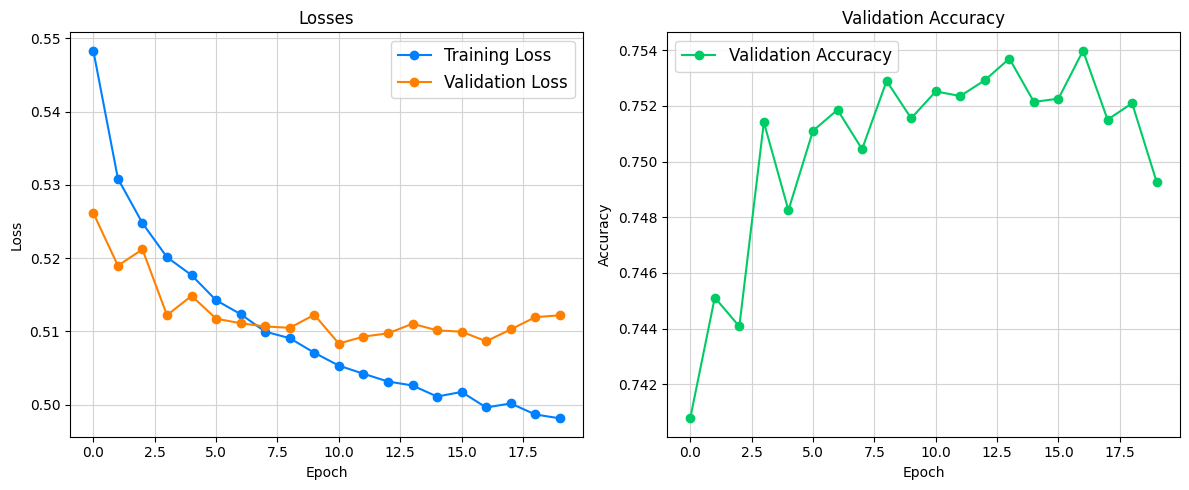

In [100]:
# Plot the results
plot_results(train_losses_v7, val_losses_v7, val_accuracies_v7)

In [101]:
# Evaluate the model
accuracy_v7, precision_v7, recall_v7, f1_score_v7, conv_matrix_v7 = evaluate_model(model_v7, validation_loader)
print(f"Validation Accuracy: {accuracy_v7:.4f}")
print(f"Validation Precision: {precision_v7:.4f}")
print(f"Validation Recall: {recall_v7:.4f}")
print(f"Validation F1 Score: {f1_score_v7:.4f}")

Started evaluation...
Evaluation Done! | Time elapsed: 3.3957626819610596 seconds
Validation Accuracy: 0.7493
Validation Precision: 0.7505
Validation Recall: 0.7493
Validation F1 Score: 0.7490


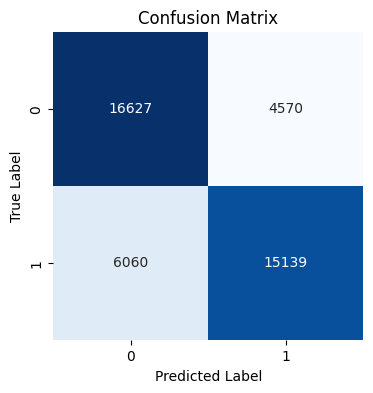

In [102]:
# Plot the confusion matrix
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
fig.patch.set_facecolor(patch_background_color)
ax.set_facecolor(patch_background_color)
plot_confusion_matrix(ax, conv_matrix_v7, classes=unique_labels)
plt.show()

#### Changing the preprocessing
In the first project we noticed that the deletion of stop-words with stemming and lemmatization actually reduced the accuracy of the model. We will also try to remove the stop-words deletion, stemming and lemmatization procedures in this notebook too.

In [103]:
def clean_text(text: str) -> str:
    ''' Text preprocessing function without stop-words removal, stemming and lemmatization '''
    text = text.lower() # Convert to lowercase
    text = contractions.fix(text) # Expand contractions
    text = re.sub(r"http\S+|www\S+|https\S+", "", text) # Remove url links
    text = re.sub(r"@\w+", "", text) # Remove mentions
    text = re.sub(r"#(\w+)", "", text) # Remove hastags
    text = re.sub(r"(?<!\.)\.(?!\.)|[^\w\s\?\!]", "", text)
    text = re.sub(r"\.\.\.", " ... ", text)  # Ensure '...' is treated as a single token

    text = re.sub(r"&[^;\s]+;", "", text) # Remove special characters
    text = re.sub(r"\s+", " ", text) # Remove extra spaces

    text = re.sub(r"\d+", "", text)

    return text

In [104]:
# Clean the datasets
train_df['Cleaned_text'] = train_df['Text'].apply(clean_text)
val_df['Cleaned_text'] = val_df['Text'].apply(clean_text)
test_df['Cleaned_text'] = test_df['Text'].apply(clean_text)

In [105]:
# Redefine the datasets and the dataloaders
train_dataset = TextDataset_GoogleNews(
    train_df['Cleaned_text'].reset_index(drop=True),
    train_df['Label'].reset_index(drop=True),
    google_news_embeddings_model
)
validation_dataset = TextDataset_GoogleNews(
    val_df['Cleaned_text'].reset_index(drop=True),
    val_df['Label'].reset_index(drop=True),
    google_news_embeddings_model
)
test_dataset = TestTextDataset_GoogleNews(
    test_df['Cleaned_text'].reset_index(drop=True),
    google_news_embeddings_model
)
# Construct the dataloaders
train_loader = DataLoader(train_dataset, batch_size=trial.params['batch_size'], shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=trial.params['batch_size'], shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=trial.params['batch_size'], shuffle=False)

In [106]:
# Define the model
model_v8 = SentimentClassifier_V7(
    input_dim, trial.params['num_layers'], trial.params['neurons_per_layer'], trial.params['dropout_rate']
).to(device)

# Redefine hyperparameters
epochs = 20
learning_rate = trial.params['learning_rate']
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.RMSprop(
    model_v8.parameters(), lr=trial.params['learning_rate'], weight_decay=trial.params['weight_decay']
)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)

In [107]:
# Train the model
train_losses_v8, val_losses_v8, val_accuracies_v8 = train_model(
    model_v8, train_loader, validation_loader, criterion, optimizer, scheduler, device, epochs
)

Training Process Started. 
Training for 20 epochs with a learning rate scheduler...
Epoch [1/20] | Training Loss: 0.53156 | Validation Loss: 0.50826 | Validation Accuracy: 0.7529
Epoch [3/20] | Training Loss: 0.50571 | Validation Loss: 0.49579 | Validation Accuracy: 0.7608
Epoch [5/20] | Training Loss: 0.49858 | Validation Loss: 0.49111 | Validation Accuracy: 0.7646
Epoch [7/20] | Training Loss: 0.49400 | Validation Loss: 0.49067 | Validation Accuracy: 0.7651
Epoch [9/20] | Training Loss: 0.49050 | Validation Loss: 0.48912 | Validation Accuracy: 0.7657
Epoch [11/20] | Training Loss: 0.48804 | Validation Loss: 0.49129 | Validation Accuracy: 0.7644
Epoch [13/20] | Training Loss: 0.48537 | Validation Loss: 0.48818 | Validation Accuracy: 0.7678
Epoch [15/20] | Training Loss: 0.48288 | Validation Loss: 0.48826 | Validation Accuracy: 0.7668
Epoch [17/20] | Training Loss: 0.48228 | Validation Loss: 0.48894 | Validation Accuracy: 0.7671
Epoch [19/20] | Training Loss: 0.48007 | Validation Loss:

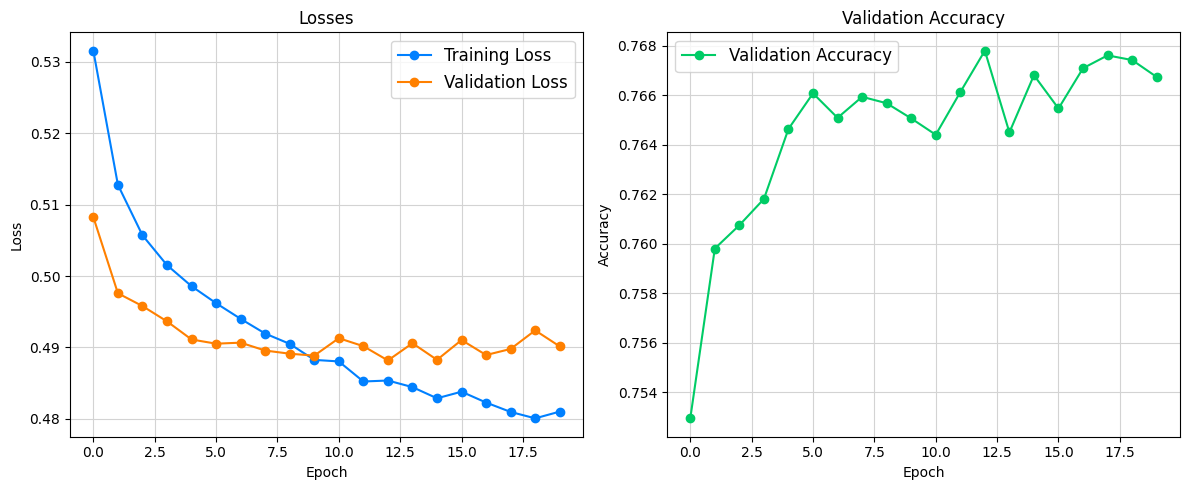

In [108]:
# Plot the results
plot_results(train_losses_v8, val_losses_v8, val_accuracies_v8)

In [109]:
# Evaluate the model
accuracy_v8, precision_v8, recall_v8, f1_score_v8, conv_matrix_v8 = evaluate_model(model_v8, validation_loader)
print(f"Validation Accuracy: {accuracy_v8:.4f}")
print(f"Validation Precision: {precision_v8:.4f}")
print(f"Validation Recall: {recall_v8:.4f}")
print(f"Validation F1 Score: {f1_score_v8:.4f}")

Started evaluation...
Evaluation Done! | Time elapsed: 3.6694552898406982 seconds
Validation Accuracy: 0.7667
Validation Precision: 0.7676
Validation Recall: 0.7667
Validation F1 Score: 0.7666


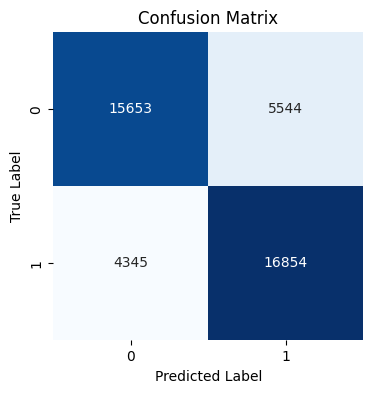

In [110]:
# Plot the confusion matrix
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
fig.patch.set_facecolor(patch_background_color)
ax.set_facecolor(patch_background_color)
plot_confusion_matrix(ax, conv_matrix_v8, classes=unique_labels)
plt.show()

By seeing these results we notice better accuracy to the validation data, although worse model generalization to the data. The maximum accuracy we can get is **0.7730**. Let's construct the submission dataframe of the test data.

### Testing Evaluation
Finally we will generate predictions for our **testing** data and we are going to save them into a **dataframe**

#### Test Dataset and Dataloader
Firstly we will construct a **dataset** and a **dataloader** for the testing dataset.

In [111]:
# Create datasets and dataloaders for the test set
test_dataset = TestTextDataset_GoogleNews(
    test_df['Cleaned_text'].reset_index(drop=True),
    google_news_embeddings_model
)
test_loader = DataLoader(test_dataset, batch_size=trial.params['batch_size'], shuffle=False)

#### Predicting
Next we will use our best model to generate predictions, and we will generate some predictions for our testing dataset. Finally we are going to store these predictions into a **Pandas Dataframe** and save them as a .csv file.

In [112]:
# Use the best model and set it to evaluation mode for generating predictions
model_v8.eval()
all_test_preds = []

# Generate predictions for the test set
for X_batch in test_loader:
    X_batch = X_batch.to(device)
    y_pred = model_v8(X_batch)
    _, predicted = torch.max(y_pred, 1)
    all_test_preds.extend(predicted.cpu().numpy())

# Create a DataFrame to store the results
submission_df = pd.DataFrame({'ID': test_df['ID'], 'Label': all_test_preds})
submission_df.to_csv('submission.csv', index=False)
submission_df

,ID,Label
8413,76944,0
7254,10095,1
15875,180574,0
13156,80484,0
20685,102648,0
...,...,...
10527,6377,1
14416,127171,1
2001,2852,0
10848,97909,1
